# BNP Paribas.

# Bussines Case Project 2025/2026

Group:V
   - Alano Gonçalves (20250457)
   - Catarina ()
   - João Carichas (20250507)
   - Marta Ribeiro ()
   - Nicole Nogeira()

# Index

- [1. Import](#import)
  - [1.1 Import libraries](#import-libraries)
  - [1.2 Import the dataset](#import-the-dataset)
- [2. Data Exploration](#data-Exploration)
  - [2.1 MetaData](#metadata)
  - [2.2 Analysing the Data](#Analysing-the-Data)
  - [2.3 Data Visualization](#Data-visualization)
  - [2.4 Correlation Check](#correlation-check)
- [3. Data Quality & Feature Engineering](#Data-Quality-&-Feature-Engineering)
  - [3.1 Data Quality](#Data-Quality)
  - [3.2 Feature Engineering](#Feature-Engineering)
- [4. Implications for Clustering](#Implications-for-Clustering)
  

<div class="alert alert-block alert-info">

<a class="anchor" id="1. Import">    </a>
# 1. Import
       
</div>


[Back to Index](#index)

<a class="anchor" id="1.1 Import Libraries">

## 1.1 Import Libraries
    
</a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil
from sklearn.impute import KNNImputer

<a class="anchor" id="1.2 Import the Dataset">

## 1.2 Import the Dataset
    
</a>

In [2]:
#!pip install pandas pyarrow
#!pip install fastparquet

In [3]:
file_path_CRC = r"C:/Users/jcari/OneDrive/Ambiente de Trabalho/NOVA IMS/Business Cases/Case 1/crc.parquet"
file_path_CREDSCORE = r"C:/Users/jcari/OneDrive/Ambiente de Trabalho/NOVA IMS/Business Cases/Case 1/BNP-Paribas-main/BNP-Paribas/credscore.parquet"
file_path_BDOSS = r"C:/Users/jcari/OneDrive/Ambiente de Trabalho/NOVA IMS/Business Cases/Case 1/bdoss.parquet"
file_path_FAMA = r"C:/Users/jcari/OneDrive/Ambiente de Trabalho/NOVA IMS/Business Cases/Case 1/BNP-Paribas-main/BNP-Paribas/fama.parquet"

# Ler o ficheiro parquet
CRC = pd.read_parquet(file_path_CRC, engine="fastparquet")
CREDSCORE = pd.read_parquet(file_path_CREDSCORE, engine="fastparquet")
FAMA = pd.read_parquet(file_path_FAMA, engine="fastparquet")
BDOSS = pd.read_parquet(file_path_BDOSS, engine="fastparquet")

<div class="alert alert-block alert-info">

<a class="anchor" id="2. Data Exploration">    </a>
# 2. Data Exploration
       
</div>


[Back to Index](#index)

<a class="anchor" id="2.1 MetaData">

## 2.1 MetaData

<a class="anchor" id="2.2 Analysing the Data">

## 2.2 Analysing the Data
    
</a>

<a class="anchor" id="2.2.1 CRC">

## 2.2.1 CRC
    
</a>

In [4]:
CRC.head()

,CONTRIB,OBS_DATE,MT_MENSAL,COUNT_CL,COUNT_CP,COUNT_AUTO,COUNT_HT,COUNT_CONEXO,COUNT_OTHER,COUNT_TOTAL,...,MONTVENC_AUTO,MONTVENC_HT,MONTABATV_CL,MONTABATV_CP,MONTABATV_AUTO,MONTABATV_HT,DIVIDAS_CL,DIVIDAS_CP,DIVIDAS_AUTO,DIVIDAS_HT
0,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,2023-12-31,NaN,1.0,4.0,0.0,0.0,0.0,1.0,6.0,...,0.0,0.0,0.0,0.0,0.0,0.0,6842.10,963.55,0.00,0.00
1,0000ab2116257783438c70ff85a3e98f2d4194ebe53434...,2023-12-31,547.18,4.0,5.0,0.0,0.0,0.0,1.0,10.0,...,0.0,0.0,0.0,0.0,0.0,0.0,28532.06,7115.46,0.00,0.00
2,0000f858346061c53064586a3347b34659565a6712d004...,2023-12-31,NaN,1.0,5.0,1.0,1.0,0.0,0.0,8.0,...,0.0,0.0,0.0,0.0,0.0,0.0,2957.28,2150.90,2408.56,85549.49
3,00025459b703e1c308553e83a6d545a71fe6a787c2dd1c...,2023-12-31,515.57,3.0,1.0,0.0,0.0,0.0,1.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,27120.42,152.95,0.00,0.00
4,00041ebafb1270a818c30cb1fb20d3699002196644ea8f...,2023-12-31,NaN,8.0,3.0,0.0,0.0,0.0,1.0,12.0,...,0.0,0.0,0.0,0.0,0.0,0.0,46104.39,4128.54,0.00,0.00


In [5]:
CRC.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3034921 entries, 0 to 3034920
Data columns (total 22 columns):
 #   Column          Dtype         
---  ------          -----         
 0   CONTRIB         object        
 1   OBS_DATE        datetime64[ns]
 2   MT_MENSAL       float64       
 3   COUNT_CL        float64       
 4   COUNT_CP        float64       
 5   COUNT_AUTO      float64       
 6   COUNT_HT        float64       
 7   COUNT_CONEXO    float64       
 8   COUNT_OTHER     float64       
 9   COUNT_TOTAL     float64       
 10  MONTVENC_CL     float64       
 11  MONTVENC_CP     float64       
 12  MONTVENC_AUTO   float64       
 13  MONTVENC_HT     float64       
 14  MONTABATV_CL    float64       
 15  MONTABATV_CP    float64       
 16  MONTABATV_AUTO  float64       
 17  MONTABATV_HT    float64       
 18  DIVIDAS_CL      float64       
 19  DIVIDAS_CP      float64       
 20  DIVIDAS_AUTO    float64       
 21  DIVIDAS_HT      float64       
dtypes: datetime64[ns](

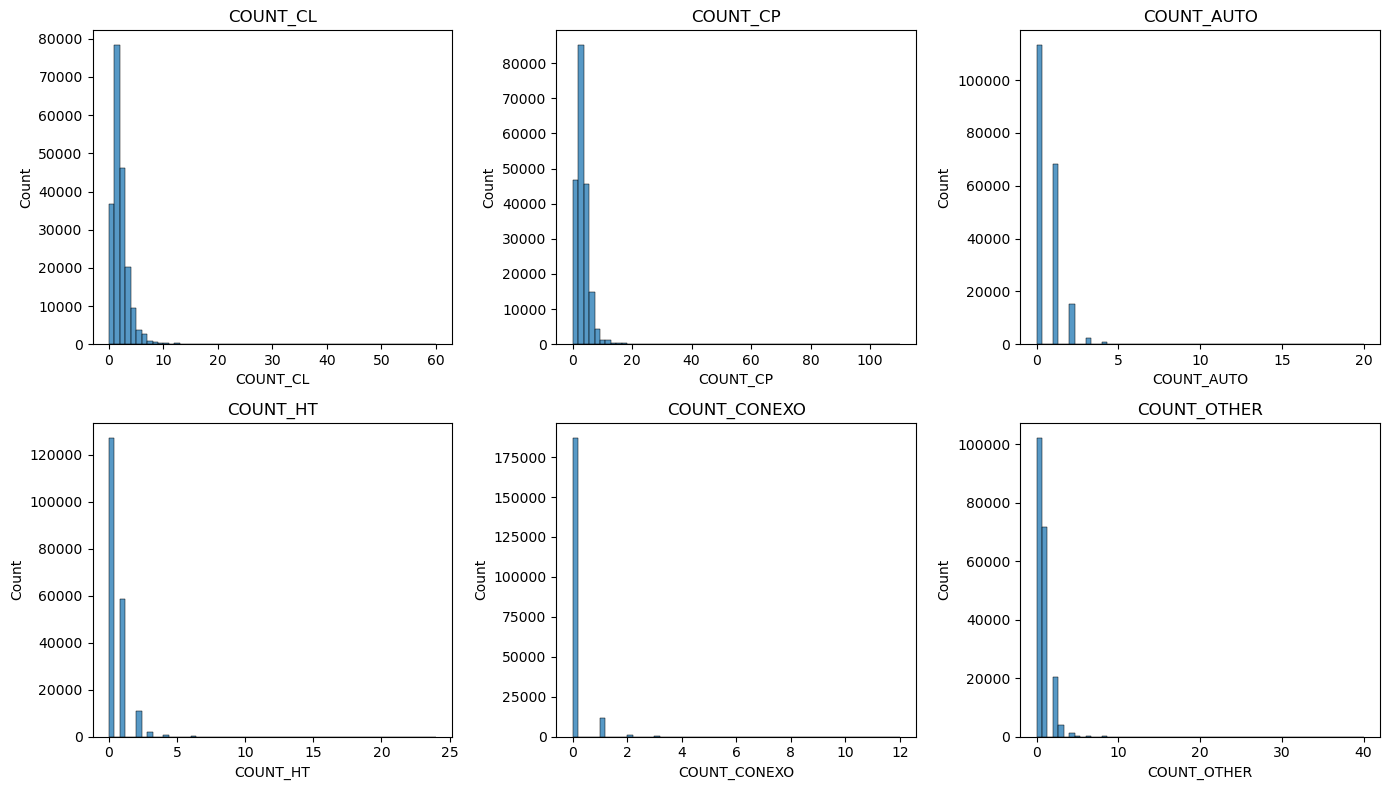

In [6]:
numeric_cols = ['COUNT_CL', 'COUNT_CP', 'COUNT_AUTO', 'COUNT_HT', 'COUNT_CONEXO', 'COUNT_OTHER', 'COUNT_TOTAL', 'MONTVENC_CL', 'MONTVENC_CP', 'MONTVENC_AUTO', 'MONTVENC_HT', 
                'MONTABATV_CL', 'MONTABATV_CP', 'MONTABATV_AUTO', 'MONTABATV_HT', 'DIVIDAS_CL', 'DIVIDAS_CP', 'DIVIDAS_AUTO', 'DIVIDAS_HT']

N = 200_000 
sample = CRC.sample(n=min(N, len(CRC)), random_state=42) 
cols = numeric_cols[:6] 

fig, axes = plt.subplots(2, 3, figsize=(14, 8)) 
axes = axes.ravel() 
for ax, col in zip(axes, cols): 
    sns.histplot(sample[col].dropna(), bins=60, kde=False, ax=ax) 
    ax.set_title(col) 

plt.tight_layout() 
plt.show()

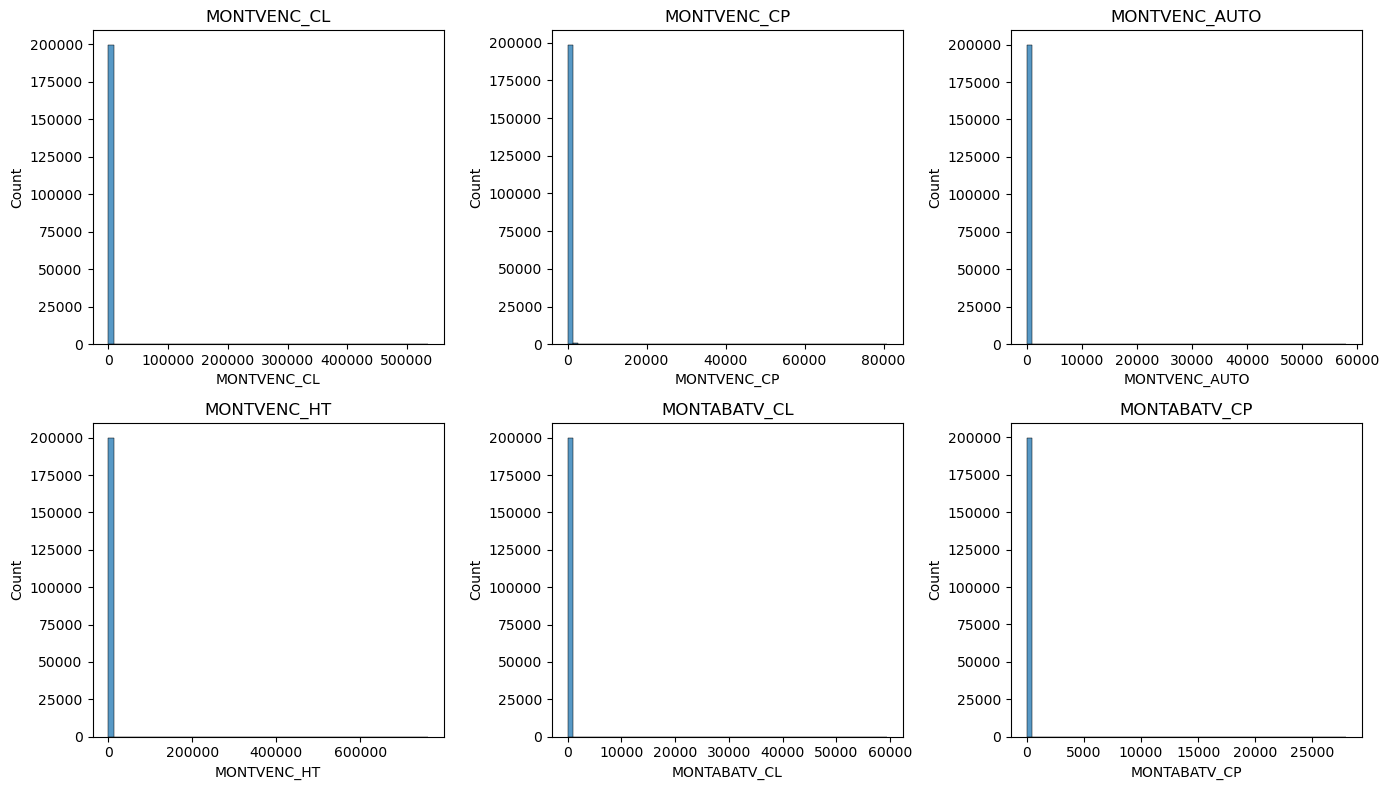

In [7]:
N = 200_000 
sample = CRC.sample(n=min(N, len(CRC)), random_state=42) 
cols = numeric_cols[7:13] 

fig, axes = plt.subplots(2, 3, figsize=(14, 8)) 
axes = axes.ravel() 
for ax, col in zip(axes, cols): 
    sns.histplot(sample[col].dropna(), bins=60, kde=False, ax=ax) 
    ax.set_title(col) 

plt.tight_layout() 
plt.show()

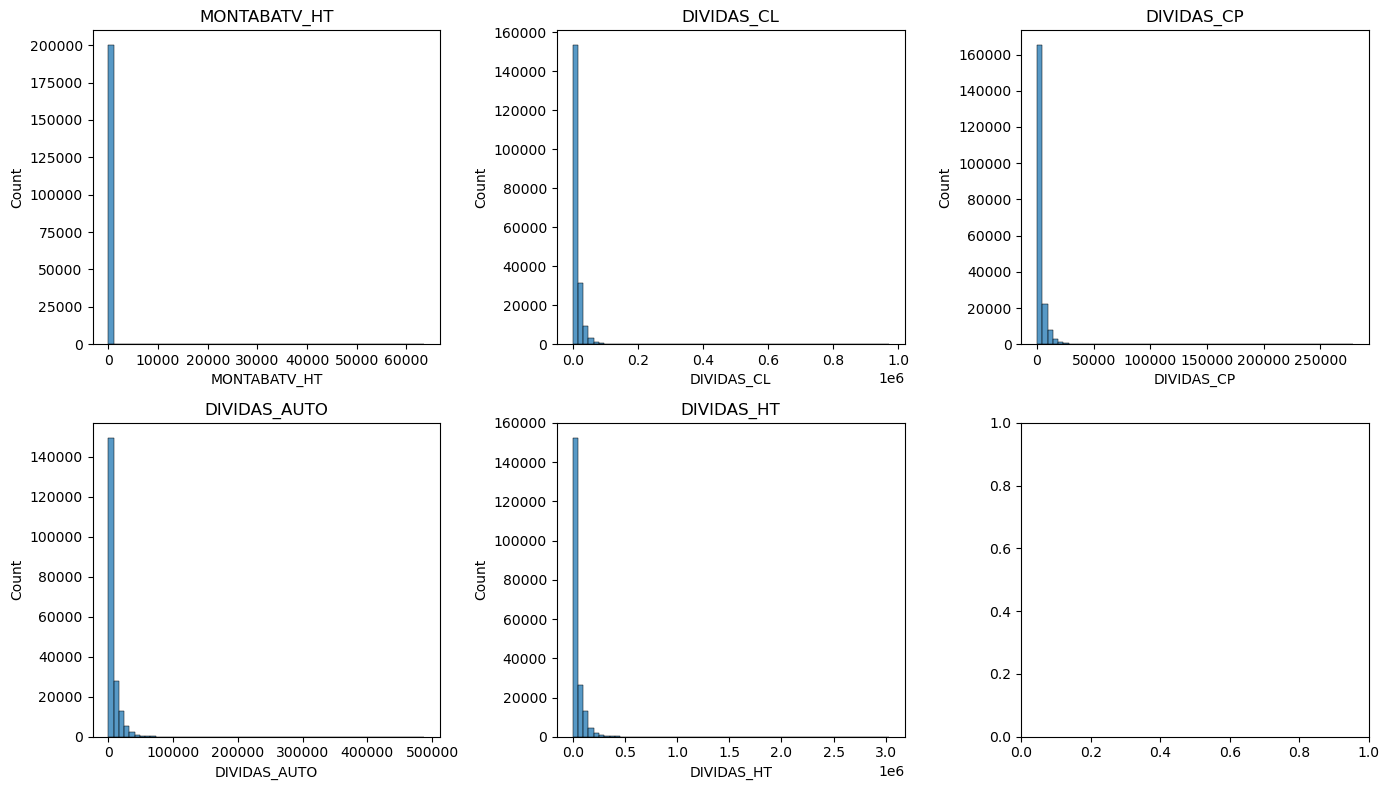

In [8]:
N = 200_000 
sample = CRC.sample(n=min(N, len(CRC)), random_state=42) 
cols = numeric_cols[14:20] 

fig, axes = plt.subplots(2, 3, figsize=(14, 8)) 
axes = axes.ravel() 
for ax, col in zip(axes, cols): 
   sns.histplot(sample[col].dropna(), bins=60, kde=False, ax=ax) 
   ax.set_title(col) 

plt.tight_layout() 
plt.show()

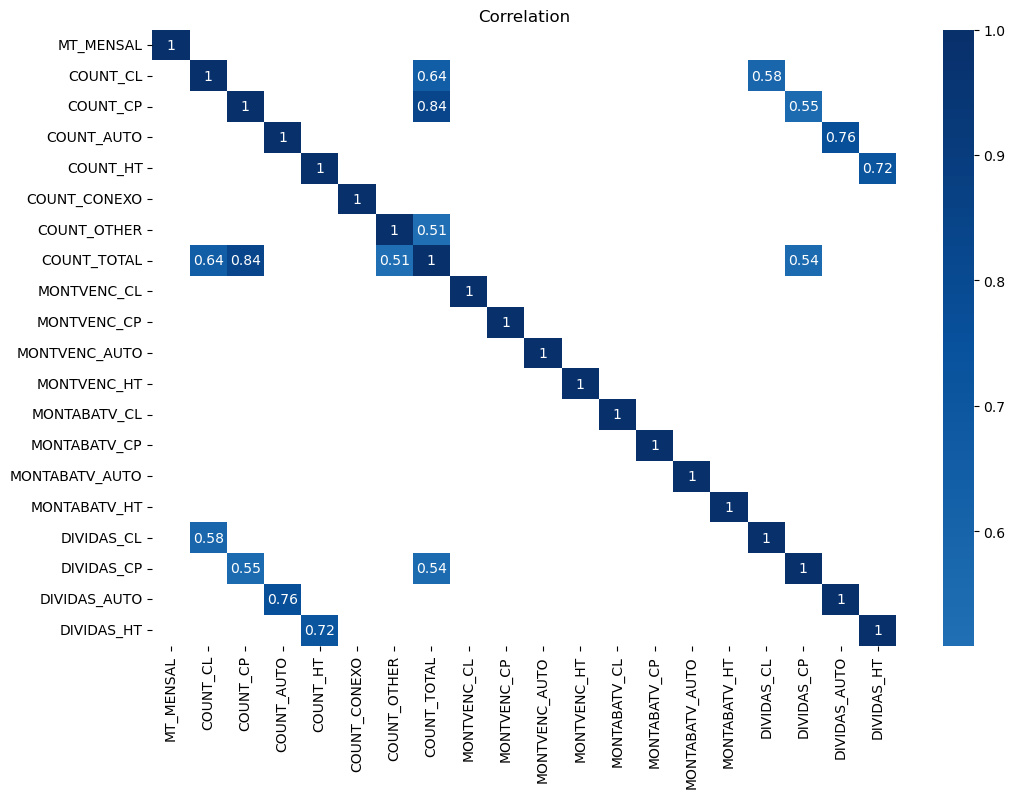

In [9]:
corr = CRC.corr(numeric_only=True)

mask = (corr.abs() < 0.5)

plt.figure(figsize=(12,8))
sns.heatmap(corr, 
            mask=mask, 
            annot=True, 
            cmap="Blues", 
            center=0)

plt.title("Correlation")
plt.show()

<a class="anchor" id="2.2.2 CREDSCORE">

## 2.2.2 CREDSCORE
    
</a>

In [10]:
CREDSCORE.head()

,CONTRIB,sys_numero_submissao,sys_data_procura,kp_sqe,ks_score_tier
0,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,22.0,2025-02-05,H,2.0
1,0000ab2116257783438c70ff85a3e98f2d4194ebe53434...,4.0,2025-04-09,D,1.0
2,00041ebafb1270a818c30cb1fb20d3699002196644ea8f...,1.0,2023-08-08,F,3.0
3,00050fe9f0e69ce221a574af0baaff0b37c598af7a5cc6...,4.0,2023-09-11,A,1.0
4,0005f134494d2ab97ed5d4164994dcde766a3f77cdb3a9...,15.0,2025-08-14,H,1.0


In [11]:
CREDSCORE.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63704 entries, 0 to 63703
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   CONTRIB               63704 non-null  object        
 1   sys_numero_submissao  63704 non-null  float64       
 2   sys_data_procura      63704 non-null  datetime64[ns]
 3   kp_sqe                45653 non-null  object        
 4   ks_score_tier         63704 non-null  float64       
dtypes: datetime64[ns](1), float64(2), object(2)
memory usage: 2.4+ MB


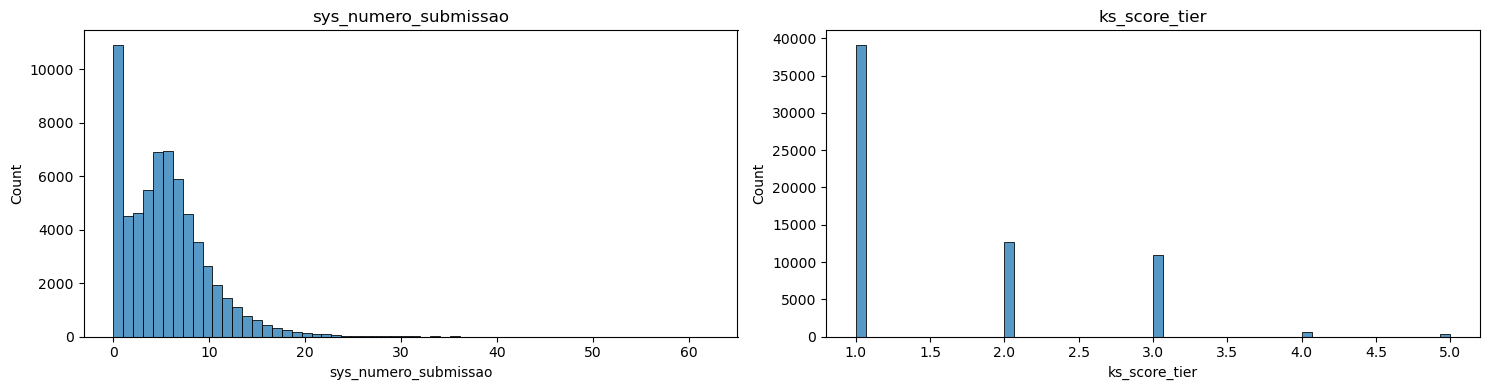

In [12]:
numeric_cols_1 = ["sys_numero_submissao","ks_score_tier"]

fig, axes = plt.subplots(1, len(numeric_cols_1), figsize=(15, 4))
axes = axes.ravel()

for ax, col in zip(axes, numeric_cols_1):
    sns.histplot(CREDSCORE[col].dropna(), bins=60, kde=False, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

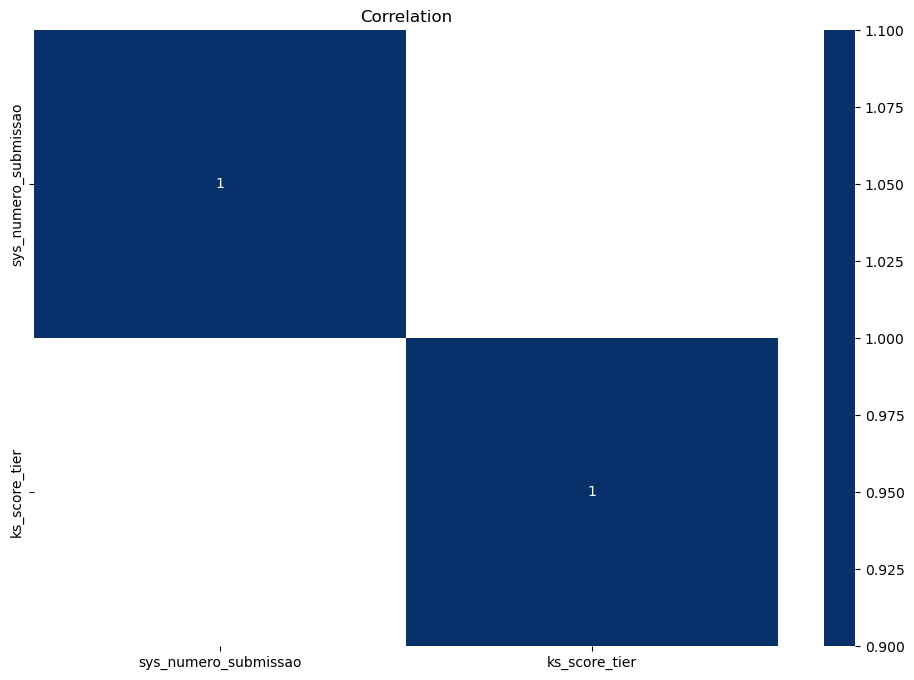

In [13]:
corr = CREDSCORE.corr(numeric_only=True)

mask = (corr.abs() < 0.5)

plt.figure(figsize=(12,8))
sns.heatmap(corr, 
            mask=mask, 
            annot=True, 
            cmap="Blues", 
            center=0)

plt.title("Correlation")
plt.show()

<a class="anchor" id="2.2.3 FAMA">

## 2.2.3 FAMA
    
</a>

In [14]:
FAMA.head()

,CONTRIB,Date_Obs,ALLBD_N_Dossiers__N,ALLBD_N_CL__N,ALLBD_N_CP__N,ALLBD_A_CL__N,ALLBD_A_CP__N,ALLBD_MTFINO_CL__N,ALLBD_MTFINO_CP__N,ALLBD_MTFIN_CL__N,...,ALLBD_IDADE_MEAN__N,ALLBD_SUM_NUMFIN_CP__N,ALLBD_mean_active_resso__N,ALLBD_max_active_resso__N,ALLBD_mean_duration_CL__N,ALLBD_mean_lifecycle_CL__N,ALLBD_N_events__N,sdem_SITFAM,sdem_HABITAT,sdem_age
0,31f4b2a40e2cc73faf9cf16c7bd6ebeea6f322931d4e0b...,2024-11-30,15.0,6.0,9.0,1.0,0.0,88784.04,0.00,88784.040000,...,1280.533333,0.0,1153.000000,1153.0,120.0,0.425000,15.0,C,P,62
1,bb7bc8dfa33e27eb832f58210a2d3282839cd2a8e7f420...,2024-11-30,6.0,4.0,2.0,1.0,2.0,9584.91,7628.41,9584.910000,...,466.333333,14.0,1564.666667,1582.0,72.0,0.138889,6.0,C,A,65
2,a377de96fc89a1aabdb5e25682e54c7d02a7209c7246d0...,2024-11-30,8.0,5.0,3.0,1.0,0.0,22000.86,0.00,22000.860000,...,907.625000,0.0,1765.000000,1765.0,36.0,0.277778,8.0,C,L,65
3,9e4d032b84105ac4981257fc993ed33f60dfec1542c723...,2024-11-30,3.0,3.0,0.0,1.0,0.0,10384.00,0.00,10384.000000,...,301.000000,0.0,840.000000,840.0,72.0,0.138889,3.0,V,P,69
4,7d0cb0079863cbf9d6d179491aab944c9af7e988d1e4bc...,2024-11-30,9.0,8.0,1.0,1.0,0.0,12866.23,0.00,13756.584246,...,2267.555556,0.0,3268.000000,3268.0,48.0,0.916667,9.0,C,A,68


In [15]:
FAMA.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141115 entries, 0 to 141114
Data columns (total 23 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   CONTRIB                     141115 non-null  object        
 1   Date_Obs                    141115 non-null  datetime64[ms]
 2   ALLBD_N_Dossiers__N         141115 non-null  float64       
 3   ALLBD_N_CL__N               141115 non-null  float64       
 4   ALLBD_N_CP__N               141115 non-null  float64       
 5   ALLBD_A_CL__N               141115 non-null  float64       
 6   ALLBD_A_CP__N               141115 non-null  float64       
 7   ALLBD_MTFINO_CL__N          141115 non-null  float64       
 8   ALLBD_MTFINO_CP__N          141115 non-null  float64       
 9   ALLBD_MTFIN_CL__N           141115 non-null  float64       
 10  ALLBD_MTFIN_CP__N           141115 non-null  float64       
 11  ALLBD_IDADE_MSA__N          141115 non-

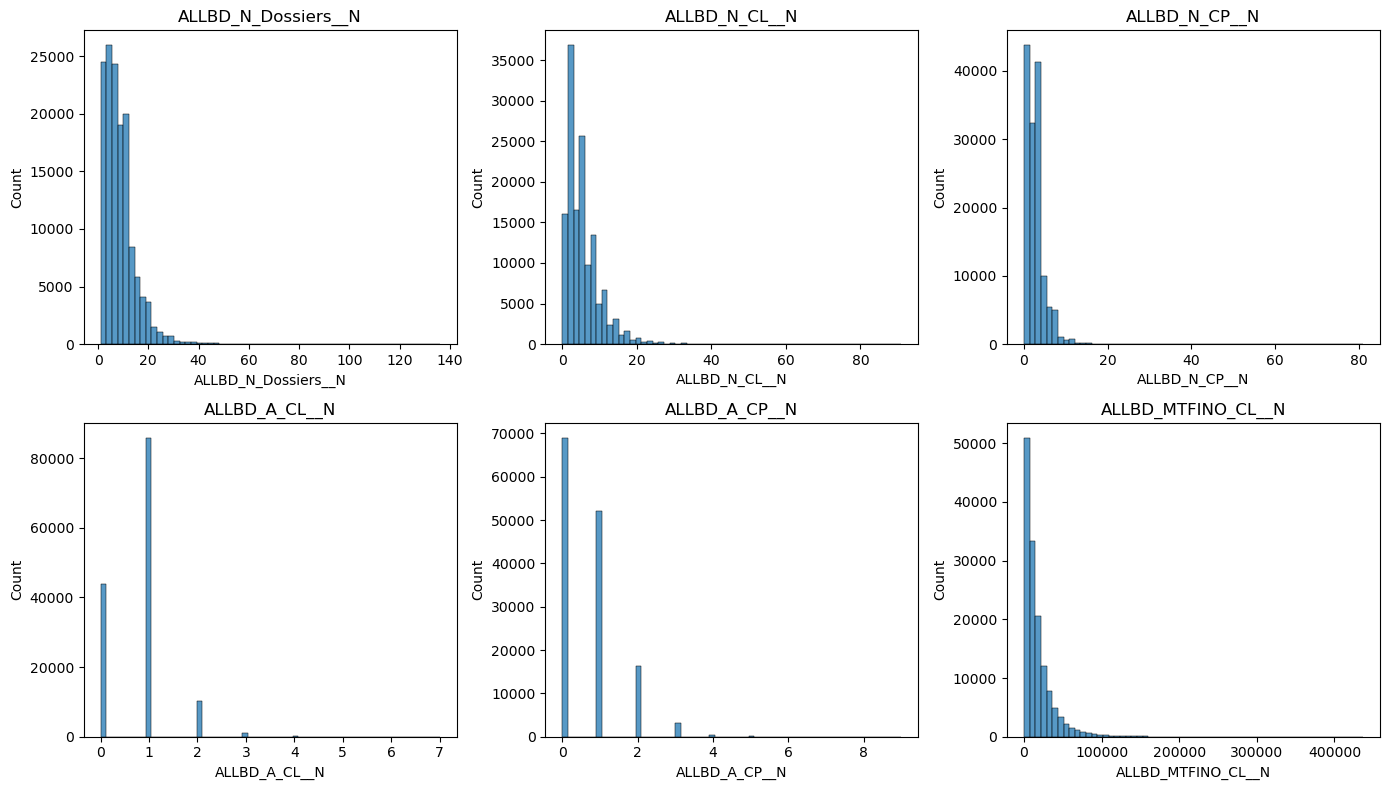

In [16]:
numeric_cols_2 = ['ALLBD_N_Dossiers__N', 'ALLBD_N_CL__N', 'ALLBD_N_CP__N',
                  'ALLBD_A_CL__N', 'ALLBD_A_CP__N', 'ALLBD_MTFINO_CL__N',
                  'ALLBD_MTFINO_CP__N', 'ALLBD_MTFIN_CL__N', 'ALLBD_MTFIN_CP__N',
                  'ALLBD_IDADE_MSA__N', 'ALLBD_IDADE_MIN__N', 'ALLBD_IDADE_MEAN__N',
                  'ALLBD_SUM_NUMFIN_CP__N', 'ALLBD_mean_active_resso__N',
                  'ALLBD_max_active_resso__N', 'ALLBD_mean_duration_CL__N',
                  'ALLBD_mean_lifecycle_CL__N', 'ALLBD_N_events__N',
                  'sdem_SITFAM', 'sdem_HABITAT', 'sdem_age']

cols = numeric_cols_2[:6]  # apenas 6

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

for ax, col in zip(axes, cols):
    sns.histplot(FAMA[col].dropna(), bins=60, kde=False, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

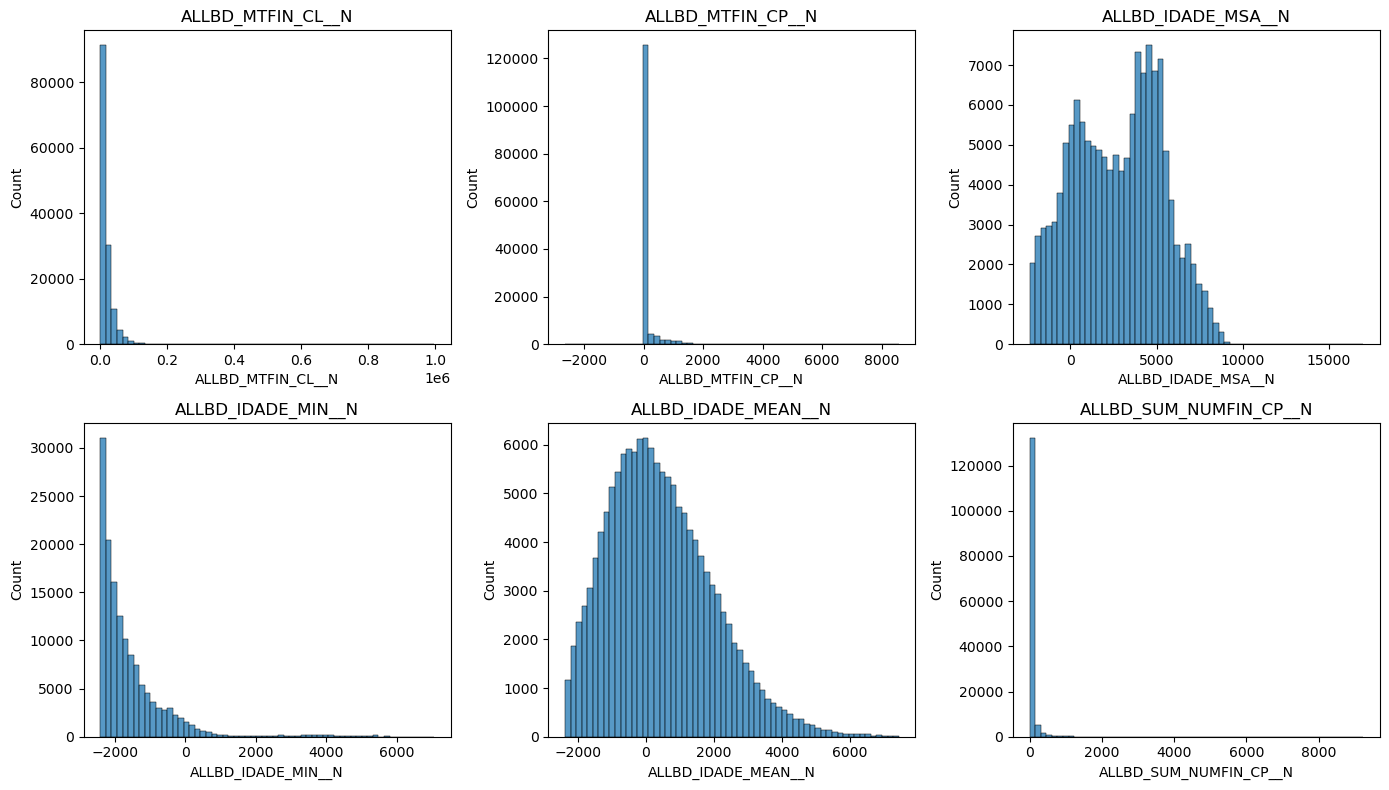

In [17]:
cols = numeric_cols_2[7:13]  # apenas 6

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

for ax, col in zip(axes, cols):
    sns.histplot(FAMA[col].dropna(), bins=60, kde=False, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

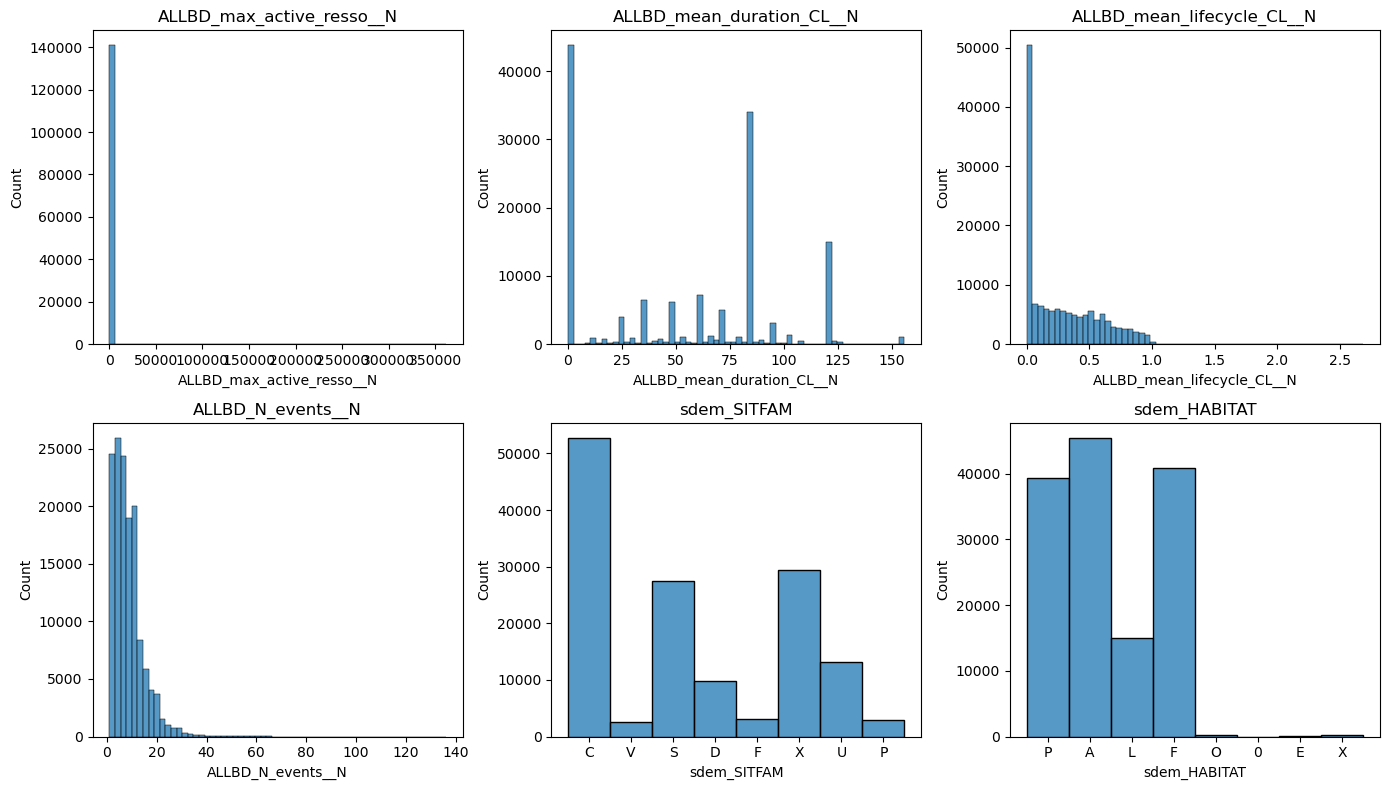

In [18]:
cols = numeric_cols_2[14:20]  # apenas 6

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

for ax, col in zip(axes, cols):
    sns.histplot(FAMA[col].dropna(), bins=60, kde=False, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

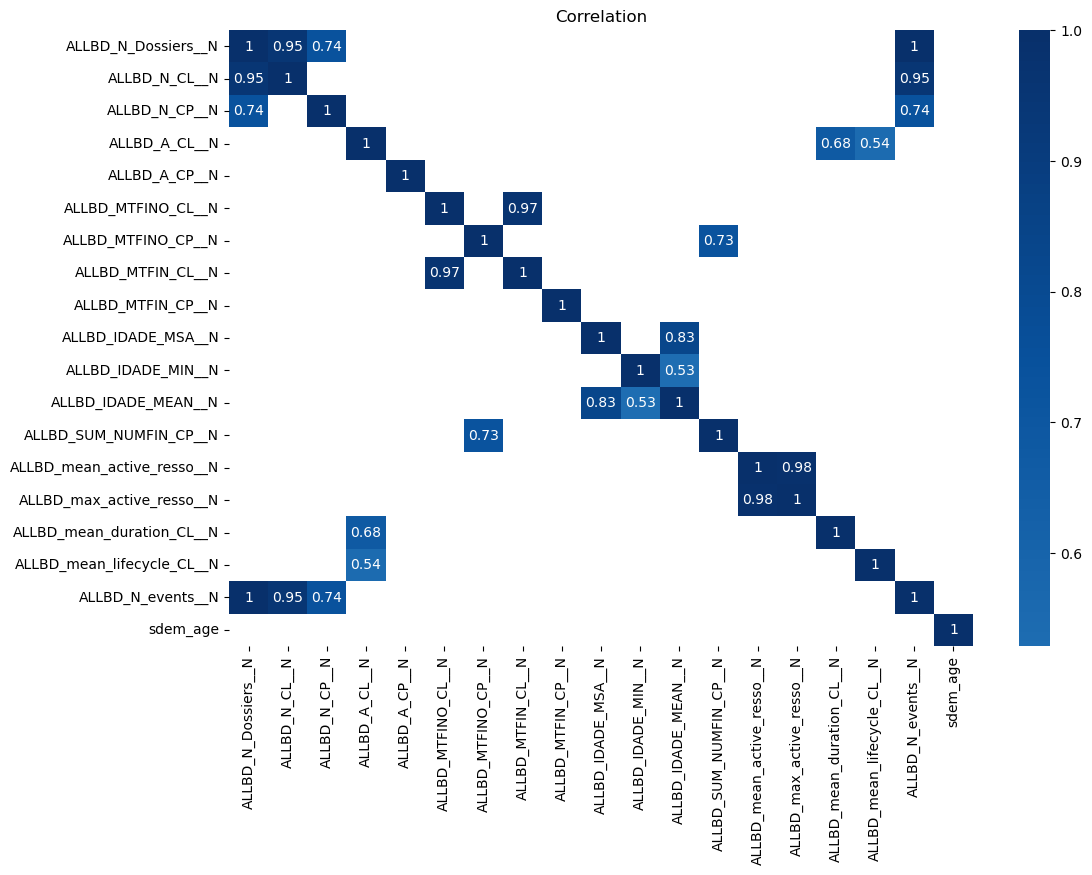

In [19]:
corr = FAMA.corr(numeric_only=True)

mask = (corr.abs() < 0.5)

plt.figure(figsize=(12,8))
sns.heatmap(corr, 
            mask=mask, 
            annot=True, 
            cmap="Blues", 
            center=0)

plt.title("Correlation")
plt.show()

<a class="anchor" id="2.2.4 BDOSS">

## 2.2.4 BDOSS
    
</a>

In [20]:
pd.set_option('display.max_columns', None)
BDOSS.head()

,CONTRIB,DOSSIER,POLE,TYPEPROD,PRODALP,BICONTRATO,POS,OBS_DATE,DCREAT,DATFIN,D1FIN,DPOS,DURDEG,RANGPRO,RANGCLI,MTFINO,MTFIN,MENSALIDADE,MENSALIDADE_CORR,CRD,SREC,ACTIVIDADE_GLOBAL,RN,RD,RISK,RISKA,AGFIN,PAGAMENTO,RESSO,CSP,DCSP,NATIO,PTT,NBENF,MODCONTACTO
0,0000ab2116257783438c70ff85a3e98f2d4194ebe53434...,9e4d186f6f66f2da4b816cbc6f6e05e640caf5ded07956...,P,CL,EP,0.0,ENC,2024-01-31,2018-03-29,2018-04-16,2018-04-16,2018-04-16,120.0,69.0,69.0,20000.0,20000.0,347.447280,NaN,13208.455,0.000,NaN,0.0,0.0,000000000000000000000000,0.0,120.0,P,1113.258,80.0,1988.0,P,2845,1.0,A
1,0000e359b15a80ba12c7f60c0fe06ffc68621c87f13a4f...,b83e6ef0c9c12f8304d86c40458a5b88ec72e534201c32...,P,CL,EP,0.0,SAN,2024-01-31,2019-01-28,2019-02-04,2019-02-04,2022-12-28,72.0,34.0,34.0,2500.0,2500.0,56.017772,NaN,0.000,0.000,NaN,1.0,1.0,000000000000210210000110,0.0,120.0,N,838.186,91.0,1990.0,P,2855,0.0,A
2,0000f858346061c53064586a3347b34659565a6712d004...,29c3cfb34c4e2ecd6749b0c1a6205dfce33c0e71751456...,P,CL,EP,0.0,ENC,2024-01-31,2019-09-23,2019-09-30,2019-09-30,2019-09-30,84.0,52.0,52.0,5000.0,5000.0,100.073575,NaN,2665.191,0.000,NaN,0.0,0.0,000000000000000000000000,0.0,118.0,P,1314.144,80.0,2013.0,P,2635,2.0,W
3,00025459b703e1c308553e83a6d545a71fe6a787c2dd1c...,446d96905d26356fb4f1d3e1e6da3868b8106b09a558e6...,P,CL,EPF,0.0,ENC,2024-01-31,2023-01-09,2023-01-13,2023-01-13,2023-01-13,60.0,13.0,37.0,6000.0,6000.0,162.097525,NaN,5893.092,0.000,NaN,0.0,0.0,000000000000000000000000,0.0,117.0,P,1031.650,80.0,1989.0,P,5090,0.0,A
4,00041ebafb1270a818c30cb1fb20d3699002196644ea8f...,26d59ea8a93be739e9fc4a0404f07c73aae276243e5cd6...,N,CL,EXT,0.0,ENC,2024-01-31,2021-02-10,2021-02-17,2021-02-17,2024-01-31,84.0,32.0,32.0,20500.0,20500.0,463.755537,NaN,17844.618,-463.756,NaN,2.0,4.0,000000000000000002112122,0.0,119.0,P,1113.258,80.0,2019.0,P,2835,0.0,A


In [21]:
BDOSS.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2658187 entries, 0 to 2658186
Data columns (total 35 columns):
 #   Column             Dtype         
---  ------             -----         
 0   CONTRIB            object        
 1   DOSSIER            object        
 2   POLE               object        
 3   TYPEPROD           object        
 4   PRODALP            object        
 5   BICONTRATO         float64       
 6   POS                object        
 7   OBS_DATE           datetime64[ns]
 8   DCREAT             datetime64[ns]
 9   DATFIN             datetime64[ns]
 10  D1FIN              datetime64[ns]
 11  DPOS               datetime64[ns]
 12  DURDEG             float64       
 13  RANGPRO            float64       
 14  RANGCLI            float64       
 15  MTFINO             float64       
 16  MTFIN              float64       
 17  MENSALIDADE        float64       
 18  MENSALIDADE_CORR   float64       
 19  CRD                float64       
 20  SREC               float

In [22]:
BDOSS['BICONTRATO'] = BDOSS['BICONTRATO'].round().astype('Int32')
BDOSS['DURDEG'] = BDOSS['DURDEG'].round().astype('Int32')
BDOSS['RANGPRO'] = BDOSS['RANGPRO'].round().astype('Int32')
BDOSS['RANGCLI'] = BDOSS['RANGCLI'].round().astype('Int32')
BDOSS['RISKA'] = BDOSS['RISKA'].round().astype('Int32')

In [23]:
BDOSS.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
CONTRIB,2658187,148729,364aad4f1733591b129753f295cca317a449f207c209bd...,158,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DOSSIER,2658187,185592,f8908577ee5bab0f764f1f007f439370b0511585b89d96...,46,NaN,NaN,NaN,NaN,NaN,NaN,NaN
POLE,2658187,2,P,2615205,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TYPEPROD,2658187,1,CL,2658187,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PRODALP,2658187,4,EP,1912612,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BICONTRATO,2658187.0,<NA>,<NA>,<NA>,0.0,0.0,0.0,0.0,0.0,0.0,0.0
POS,2658187,4,ENC,2214397,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OBS_DATE,2658187,NaN,NaN,NaN,2024-12-31 12:04:59.079635456,2024-01-31 00:00:00,2024-06-30 00:00:00,2024-12-31 00:00:00,2025-06-30 00:00:00,2025-11-30 00:00:00,NaN
DCREAT,2658187,NaN,NaN,NaN,2022-03-23 09:42:27.446511104,1996-06-14 00:00:00,2020-11-24 00:00:00,2022-10-20 00:00:00,2024-01-31 00:00:00,2025-12-02 00:00:00,NaN
DATFIN,2658187,NaN,NaN,NaN,2022-04-01 11:27:02.187001088,1996-06-17 00:00:00,2020-12-02 00:00:00,2022-10-28 00:00:00,2024-02-07 00:00:00,2025-12-02 00:00:00,NaN


## **Documentação:**

**- Duplicates**

In [24]:
BDOSS.duplicated().sum()

np.int64(0)

**- Missing Values**

In [25]:
BDOSS.isna().sum()[BDOSS.isna().sum() > 0]

RANGCLI                    1
MENSALIDADE_CORR     2658187
ACTIVIDADE_GLOBAL    2658187
DCSP                  293663
NATIO                      1
NBENF                    736
MODCONTACTO            59544
dtype: int64

In [26]:
#checking umber of missing values in each column as a percentage
BDOSS.isna().sum()[BDOSS.isna().sum() > 0]/len(BDOSS) * 100

RANGCLI                0.000038
MENSALIDADE_CORR     100.000000
ACTIVIDADE_GLOBAL    100.000000
DCSP                  11.047492
NATIO                  0.000038
NBENF                  0.027688
MODCONTACTO            2.240023
dtype: float64

**- Constant Features**

In [27]:
BDOSS['MENSALIDADE_CORR'].unique()

array([nan])

In [28]:
BDOSS['ACTIVIDADE_GLOBAL'].unique()

array([nan])

In [29]:
BDOSS['TYPEPROD'].unique()

array(['CL'], dtype=object)

In [30]:
BDOSS['BICONTRATO'].unique()

<IntegerArray>
[0]
Length: 1, dtype: Int32

**- RISK and RISKA:**

In [31]:
BDOSS['RISK'].value_counts()

RISK
000000000000000000000000    2327930
444444444444444444444444      23863
000000000000000000000001      16652
000000000000000000000010       7487
000000000000000000000100       6278
                             ...   
010000100001000111122010          1
000000100000000010101010          1
012222222122221221111221          1
000001122222221221122100          1
000110210110000000211221          1
Name: count, Length: 77475, dtype: int64

In [32]:
BDOSS['RISKA'].value_counts()

RISKA
0    2571156
1      79077
7       7954
Name: count, dtype: Int64

In [33]:
BDOSS['NBENF'].value_counts() #valores outliers

NBENF
0.0     1538648
1.0      664154
2.0      385790
3.0       59785
4.0        7713
5.0        1288
8.0          23
7.0          23
10.0         11
52.0          8
6.0           6
90.0          2
Name: count, dtype: int64

In [34]:
BDOSS['AGFIN'].value_counts()

AGFIN
118.0    1229325
117.0     720161
120.0     518201
119.0     146805
525.0      39560
112.0       3963
111.0         66
500.0         48
503.0         46
116.0          6
100.0          6
Name: count, dtype: int64

posiçoes relativas a churn:

In [35]:
BDOSS['POS'].unique()

array(['ENC', 'SAN', 'SOL', 'RBT'], dtype=object)

In [36]:
BDOSS['POS'].value_counts()

POS
ENC    2214397
SAN     275931
SOL     152934
RBT      14925
Name: count, dtype: int64

apenas queremos P?

In [37]:
BDOSS['POLE'].value_counts()

POLE
P    2615205
N      42982
Name: count, dtype: int64

nenhum deles aparece no metadata:

In [38]:
BDOSS['PRODALP'].unique()

array(['EP', 'EPF', 'EXT', 'DEF'], dtype=object)

---

In [39]:
BDOSS['CSP'].unique()#54, 58, 50, 56, 55, 57, 52, 53, 0 e 51 nao aparecem no metadata

array([80., 91., 35., 60., 90., 54., 70., 31., 74., 20., 58., 15., 41.,
       10., 50., 33., 56., 55., 86., 32., 30., 92., 57., 52., 53., 34.,
       40., 81., 99.,  0., 96., 25., 51.])

In [40]:
estranhos = [54, 58, 50, 56, 55, 57, 52, 53, 0, 51]
result = 0
for num in BDOSS['CSP']:
    if num in estranhos:
        result = result + 1
print(result)

161453


In [41]:
result / len(BDOSS['CSP']) * 100

6.073801429320059

---

In [42]:
BDOSS['CSP'].tolist()

[80.0,
 91.0,
 80.0,
 80.0,
 80.0,
 80.0,
 35.0,
 60.0,
 90.0,
 80.0,
 80.0,
 60.0,
 60.0,
 90.0,
 80.0,
 80.0,
 80.0,
 54.0,
 70.0,
 60.0,
 31.0,
 31.0,
 80.0,
 74.0,
 80.0,
 80.0,
 60.0,
 20.0,
 31.0,
 31.0,
 60.0,
 60.0,
 35.0,
 70.0,
 31.0,
 31.0,
 80.0,
 80.0,
 80.0,
 58.0,
 70.0,
 31.0,
 15.0,
 80.0,
 80.0,
 35.0,
 74.0,
 80.0,
 60.0,
 90.0,
 80.0,
 60.0,
 80.0,
 80.0,
 35.0,
 41.0,
 80.0,
 10.0,
 50.0,
 41.0,
 80.0,
 80.0,
 80.0,
 80.0,
 80.0,
 60.0,
 31.0,
 80.0,
 80.0,
 60.0,
 60.0,
 33.0,
 70.0,
 60.0,
 80.0,
 60.0,
 60.0,
 60.0,
 70.0,
 80.0,
 60.0,
 60.0,
 60.0,
 60.0,
 60.0,
 60.0,
 60.0,
 80.0,
 50.0,
 90.0,
 60.0,
 60.0,
 60.0,
 60.0,
 31.0,
 31.0,
 60.0,
 60.0,
 70.0,
 70.0,
 70.0,
 80.0,
 80.0,
 31.0,
 80.0,
 90.0,
 60.0,
 91.0,
 60.0,
 80.0,
 70.0,
 70.0,
 60.0,
 70.0,
 70.0,
 80.0,
 80.0,
 56.0,
 80.0,
 60.0,
 60.0,
 35.0,
 35.0,
 74.0,
 31.0,
 70.0,
 60.0,
 60.0,
 31.0,
 55.0,
 60.0,
 80.0,
 33.0,
 80.0,
 60.0,
 80.0,
 60.0,
 31.0,
 70.0,
 80.0,
 60.0,
 56.0,
 80.0,

In [43]:
BDOSS.columns

Index(['CONTRIB', 'DOSSIER', 'POLE', 'TYPEPROD', 'PRODALP', 'BICONTRATO',
       'POS', 'OBS_DATE', 'DCREAT', 'DATFIN', 'D1FIN', 'DPOS', 'DURDEG',
       'RANGPRO', 'RANGCLI', 'MTFINO', 'MTFIN', 'MENSALIDADE',
       'MENSALIDADE_CORR', 'CRD', 'SREC', 'ACTIVIDADE_GLOBAL', 'RN', 'RD',
       'RISK', 'RISKA', 'AGFIN', 'PAGAMENTO', 'RESSO', 'CSP', 'DCSP', 'NATIO',
       'PTT', 'NBENF', 'MODCONTACTO'],
      dtype='object')

---

In [44]:
BDOSS[BDOSS['RISKA'] != BDOSS['RISK'].astype(str).str[-1].astype(int)]

,CONTRIB,DOSSIER,POLE,TYPEPROD,PRODALP,BICONTRATO,POS,OBS_DATE,DCREAT,DATFIN,D1FIN,DPOS,DURDEG,RANGPRO,RANGCLI,MTFINO,MTFIN,MENSALIDADE,MENSALIDADE_CORR,CRD,SREC,ACTIVIDADE_GLOBAL,RN,RD,RISK,RISKA,AGFIN,PAGAMENTO,RESSO,CSP,DCSP,NATIO,PTT,NBENF,MODCONTACTO
4,00041ebafb1270a818c30cb1fb20d3699002196644ea8f...,26d59ea8a93be739e9fc4a0404f07c73aae276243e5cd6...,N,CL,EXT,0,ENC,2024-01-31,2021-02-10,2021-02-17,2021-02-17,2024-01-31,84,32,32,20500.0,20500.0,463.755537,NaN,17844.618,-463.756,NaN,2.0,4.0,000000000000000002112122,0,119.0,P,1113.258,80.0,2019.0,P,2835,0.0,A
53,00245abdde6b5be044bd121c4618fdcc43e90f9f0ef5bc...,64f6c53b0b8e111e029da5ea073196dbd89ae6025fd9a7...,P,CL,EP,0,SAN,2024-01-31,2022-12-29,2023-01-05,2023-01-05,2023-12-11,22,11,11,2500.0,2500.0,147.925036,NaN,0.000,0.000,NaN,1.0,3.0,000000000000020000101011,0,118.0,P,1451.493,80.0,2021.0,D,8125,2.0,W
57,0026b5f0de9828ec21d97c586dc791fb0671a0224617d1...,2b075e5032a850f4290d1b23e68320cd36cffb93f7dcc8...,P,CL,EP,0,SAN,2024-01-31,2022-02-02,2022-02-03,2022-02-03,2023-06-05,60,16,37,2500.0,2500.0,61.538164,NaN,0.000,0.000,NaN,3.0,9.0,000000002110122200122001,0,118.0,P,2009.717,10.0,2018.0,P,3090,2.0,W
72,002ddf74dace98336bfd869bdf44deab63ab07753122d6...,2a0c6243fee831fa936fc507b331b614dc6ad6b53910d6...,P,CL,EP,0,SOL,2024-01-31,2014-01-09,2014-01-22,2014-01-09,2022-10-04,84,81,81,5000.0,5000.0,118.518615,NaN,0.000,0.000,NaN,3.0,5.0,221111222112012212220111,0,119.0,P,1231.996,70.0,2009.0,P,7580,0.0,T
122,004cc9fa8892482a26231071d03ecb17c5a8779b683804...,56ca44ed01b953656bd0b46454b894de6b39d882e52279...,P,CL,EXT,0,ENC,2024-01-31,2023-04-26,2023-05-08,2023-05-05,2024-01-23,84,9,9,10343.0,10343.0,233.912421,NaN,11549.523,0.000,NaN,0.0,0.0,000000000000000000010110,1,118.0,P,2523.423,35.0,2009.0,P,2775,2.0,W
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2658123,ffddc57160d56f6899d2daa5e1a1720b5903a6e665354f...,c56d1af3fdeeceb79806b8dd25b0495f25f225b5428e88...,P,CL,EPF,0,ENC,2025-11-30,2022-01-09,2022-02-16,2022-02-16,2024-09-09,84,45,45,5000.0,5000.0,107.643659,NaN,3307.841,0.000,NaN,0.0,0.0,000010000000000000000000,1,118.0,P,313.084,52.0,NaN,P,2415,0.0,W
2658149,ffec38e28088b6290ec9ed851675f19b0182cecd14a105...,7bcb4d654fd5736dcc83846e861dfb7b2fab4b21bf7180...,P,CL,EPF,0,ENC,2025-11-30,2022-10-06,2022-10-14,2022-10-14,2025-11-28,84,38,38,11000.0,11000.0,244.084787,NaN,8467.150,0.000,NaN,0.0,0.0,000000000010001000000101,0,117.0,P,861.102,80.0,2000.0,P,3720,0.0,A
2658180,fffa9b9225bff7296ad890805ea9ccf9a105663acb1a97...,9638a80107e20c8cbf33e66fe0ffc642fee561907852dc...,P,CL,EXT,0,SAN,2025-11-30,2023-08-01,2023-08-21,2023-08-18,2025-08-12,84,23,23,24750.0,24750.0,584.152276,NaN,0.000,0.000,NaN,0.0,0.0,000000000000000001111111,0,118.0,P,1253.882,80.0,1995.0,P,4425,1.0,W
2658183,fffbc66ca4256976c9932916770f1ff3b23aacce5998ff...,dea39098d015a030ea0b3ead87c82ccca9137f784f86c7...,P,CL,EPF,0,ENC,2025-11-30,2018-12-21,2018-12-24,2018-12-24,2025-11-28,84,83,83,7430.0,7430.0,157.667572,NaN,137.403,-157.668,NaN,1.0,2.0,000000000000002001111112,0,118.0,P,977.381,31.0,2018.0,P,4820,1.0,W


In [45]:
len(BDOSS)

2658187

In [46]:
168528/2658187

0.06339960281199178

**apenas 6% das linhas têm o último valor de risk diferente de riska**

In [47]:
mask = BDOSS['RISKA'] != BDOSS['RISK'].astype(str).str[-1].astype(int)

BDOSS.loc[mask, 'RISK'] = (BDOSS.loc[mask, 'RISK'].astype(str).str[:-1] + 
                           BDOSS.loc[mask, 'RISKA'].astype(str))

In [48]:
BDOSS[BDOSS['RISKA'] != BDOSS['RISK'].astype(str).str[-1].astype(int)]

,CONTRIB,DOSSIER,POLE,TYPEPROD,PRODALP,BICONTRATO,POS,OBS_DATE,DCREAT,DATFIN,D1FIN,DPOS,DURDEG,RANGPRO,RANGCLI,MTFINO,MTFIN,MENSALIDADE,MENSALIDADE_CORR,CRD,SREC,ACTIVIDADE_GLOBAL,RN,RD,RISK,RISKA,AGFIN,PAGAMENTO,RESSO,CSP,DCSP,NATIO,PTT,NBENF,MODCONTACTO


---

**mudar estas 253 linhas para que RANGPRO == DURDEG**

In [49]:
BDOSS[BDOSS['RANGPRO'] - BDOSS['DURDEG'] > 0]

,CONTRIB,DOSSIER,POLE,TYPEPROD,PRODALP,BICONTRATO,POS,OBS_DATE,DCREAT,DATFIN,D1FIN,DPOS,DURDEG,RANGPRO,RANGCLI,MTFINO,MTFIN,MENSALIDADE,MENSALIDADE_CORR,CRD,SREC,ACTIVIDADE_GLOBAL,RN,RD,RISK,RISKA,AGFIN,PAGAMENTO,RESSO,CSP,DCSP,NATIO,PTT,NBENF,MODCONTACTO
13373,1eeda66678fe87887b4e435aa1ac405c4ee922ad6bed98...,6a73d420a9c4629486e6f5dda41f27e14de45734f835ab...,P,CL,EP,0,SOL,2024-01-31,2017-09-14,2017-09-21,2017-09-21,2023-12-01,72,73,73,7000.00,7000.00,157.190164,NaN,0.0,0.0,NaN,0.0,0.0,000000000000000000000000,0,118.0,P,1181.441,70.0,1987.0,P,2350,0.0,A
14809,22535d3248147b8e894c46602e349876a2b7a58252a7b0...,d55babf7dbe197586e7b624efb0da2d1898a90f918b7ac...,P,CL,EPF,0,SOL,2024-01-31,2015-05-22,2015-05-28,2015-05-22,2023-08-04,84,85,85,9000.46,9000.46,199.519797,NaN,0.0,0.0,NaN,1.0,1.0,100000000000000121212120,0,118.0,N,1851.117,90.0,2000.0,P,3610,1.0,None
23704,366d5bd958989f93f6e20d957959f964ddf065149bd715...,7e205ecd82246afc84cc94105be457755e0fe7ccd65b2f...,P,CL,EPF,0,SOL,2024-01-31,2016-08-08,2016-08-23,2016-08-08,2023-11-21,84,85,85,10500.00,10500.00,238.839973,NaN,0.0,0.0,NaN,1.0,0.0,000000110100200111000010,0,117.0,P,901.600,70.0,2012.0,P,2410,1.0,None
48850,7013a45ea15ab41a281691a85a99c53bb650d7b6d12745...,e0cfdfb6402b13a9540add0d348ad1d166ff5de5b99d1f...,P,CL,EPF,0,SOL,2024-01-31,2016-10-14,2016-10-24,2016-10-14,2024-01-01,84,85,85,15000.60,15000.60,341.476332,NaN,0.0,0.0,NaN,0.0,0.0,000000000000000001000000,0,117.0,P,836.839,80.0,1993.0,P,7370,0.0,None
53702,7b2db95efe1f3f55ae0566731a18ef153f7ada276c4fc3...,7c2e2cb7b349743596bd6087f9b55d20d0d2ffae927505...,P,CL,EP,0,SOL,2024-01-31,2017-10-03,2017-10-09,2017-10-09,2024-01-01,72,73,73,15000.00,15000.00,344.638483,NaN,0.0,0.0,NaN,0.0,0.0,000000000000010000000000,0,118.0,P,1045.234,60.0,2012.0,P,2675,0.0,W
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2591774,747283c8dd6c2be7c5e4d86c4adcd653c3f9381b4f0e6a...,66bb8e8c16bac641e2ff3f1cfbb4f760c310ae3c652d9e...,P,CL,EP,0,SOL,2025-11-30,2017-05-06,2017-07-12,2017-07-12,2025-09-10,96,97,97,25000.00,25000.00,476.003055,NaN,0.0,0.0,NaN,1.0,2.0,002210000000000000002210,0,118.0,P,2710.636,81.0,2016.0,P,2430,2.0,W
2592547,761e197ef3212fef89be1a88eb9d46d862c72e699dc9f6...,91f180eb8d37733c4bd4a1c1f40cce541a84039790e78d...,P,CL,EP,0,SOL,2025-11-30,2019-07-02,2019-07-08,2019-07-08,2025-10-01,72,73,73,11000.00,11000.00,248.800673,NaN,0.0,0.0,NaN,0.0,0.0,000000000000000000000000,0,120.0,P,662.454,20.0,2015.0,P,4500,2.0,A
2595126,7b4ae59459f74157e8dd76f2cb2a4418dae8818d89758c...,735d4904fb0d6a5daf2298cd7a3f1c6d2e419fc470ea3c...,P,CL,EP,0,SOL,2025-11-30,2023-08-31,2023-08-31,2023-08-31,2025-09-05,24,25,25,4000.00,4000.00,215.810828,NaN,0.0,0.0,NaN,2.0,7.0,020000000000000000000100,0,117.0,P,1238.833,74.0,2017.0,P,9300,1.0,A
2632092,c91a7037a2ec427dfb5398e8db01c486ae872b2604c0a5...,4f998ab6e24407fc3d5259d9de75fa9146bc833541686e...,P,CL,EPF,0,SOL,2025-11-30,2019-04-29,2019-04-29,2019-04-29,2025-08-11,72,73,73,16000.00,16000.00,374.958776,NaN,0.0,0.0,NaN,0.0,0.0,000000010000000000000000,0,118.0,P,2993.089,31.0,1998.0,P,3870,1.0,A


In [50]:
mask = (BDOSS['RANGPRO'] == BDOSS['DURDEG'] + 1)  #os tais 253 casos
BDOSS.loc[mask, 'RANGPRO'] = BDOSS.loc[mask, 'DURDEG']
#BDOSS.loc[mask, 'DURDEG'] = BDOSS.loc[mask, 'RANGPRO'] caso seja ao contrario

## **Feature Engineering para agregado**

**- média do historial dos 24 meses**

In [51]:
BDOSS['HISTORIAL'] = (BDOSS['RISK'].astype(str).apply(lambda x: sum(int(i) for i in x) / len(x)))

In [52]:
BDOSS.sort_values(['DOSSIER', 'OBS_DATE']).head(18)

,CONTRIB,DOSSIER,POLE,TYPEPROD,PRODALP,BICONTRATO,POS,OBS_DATE,DCREAT,DATFIN,D1FIN,DPOS,DURDEG,RANGPRO,RANGCLI,MTFINO,MTFIN,MENSALIDADE,MENSALIDADE_CORR,CRD,SREC,ACTIVIDADE_GLOBAL,RN,RD,RISK,RISKA,AGFIN,PAGAMENTO,RESSO,CSP,DCSP,NATIO,PTT,NBENF,MODCONTACTO,HISTORIAL
158127,677472a9f60eb4b38b9fd482d91b6aa47fc33b9c4065c8...,00007120b256813875f9aa390a1a97492b9b35e3eed634...,P,CL,EP,0,ENC,2024-02-29,2024-02-19,2024-02-22,2024-02-22,2024-02-22,84,0,61,2500.0,2500.0,53.066833,NaN,2923.471,0.0,NaN,1.0,8.0,000000000000000000000000,0,118.0,P,1046.593,70.0,2022.0,P,2670,0.0,W,0.0
273100,677472a9f60eb4b38b9fd482d91b6aa47fc33b9c4065c8...,00007120b256813875f9aa390a1a97492b9b35e3eed634...,P,CL,EP,0,ENC,2024-03-31,2024-02-19,2024-02-22,2024-02-22,2024-02-22,84,1,61,2500.0,2500.0,53.066833,NaN,2900.238,0.0,NaN,1.0,8.0,000000000000000000000000,0,118.0,P,1046.593,70.0,2022.0,P,2670,0.0,W,0.0
389688,677472a9f60eb4b38b9fd482d91b6aa47fc33b9c4065c8...,00007120b256813875f9aa390a1a97492b9b35e3eed634...,P,CL,EP,0,ENC,2024-04-30,2024-02-19,2024-02-22,2024-02-22,2024-02-22,84,2,61,2500.0,2500.0,53.066833,NaN,2876.781,0.0,NaN,1.0,8.0,000000000000000000000000,0,118.0,P,1046.593,70.0,2022.0,P,2670,0.0,W,0.0
506709,677472a9f60eb4b38b9fd482d91b6aa47fc33b9c4065c8...,00007120b256813875f9aa390a1a97492b9b35e3eed634...,P,CL,EP,0,ENC,2024-05-31,2024-02-19,2024-02-22,2024-02-22,2024-02-22,84,3,61,2500.0,2500.0,53.066833,NaN,2853.114,0.0,NaN,1.0,8.0,000000000000000000000000,0,118.0,P,1046.593,70.0,2022.0,P,2670,0.0,W,0.0
624006,677472a9f60eb4b38b9fd482d91b6aa47fc33b9c4065c8...,00007120b256813875f9aa390a1a97492b9b35e3eed634...,P,CL,EP,0,ENC,2024-06-30,2024-02-19,2024-02-22,2024-02-22,2024-02-22,84,4,61,2500.0,2500.0,53.066833,NaN,2829.212,0.0,NaN,1.0,8.0,000000000000000000000000,0,118.0,P,1046.593,70.0,2022.0,P,2670,0.0,W,0.0
741669,677472a9f60eb4b38b9fd482d91b6aa47fc33b9c4065c8...,00007120b256813875f9aa390a1a97492b9b35e3eed634...,P,CL,EP,0,ENC,2024-07-31,2024-02-19,2024-02-22,2024-02-22,2024-02-22,84,5,61,2500.0,2500.0,53.066833,NaN,2805.088,0.0,NaN,1.0,8.0,000000000000000000000000,0,118.0,P,1046.593,70.0,2022.0,P,2670,0.0,W,0.0
859552,677472a9f60eb4b38b9fd482d91b6aa47fc33b9c4065c8...,00007120b256813875f9aa390a1a97492b9b35e3eed634...,P,CL,EP,0,ENC,2024-08-31,2024-02-19,2024-02-22,2024-02-22,2024-02-22,84,6,61,2500.0,2500.0,53.066833,NaN,2780.741,0.0,NaN,1.0,8.0,000000000000000000000000,0,118.0,P,1046.593,70.0,2022.0,P,2670,0.0,W,0.0
975993,677472a9f60eb4b38b9fd482d91b6aa47fc33b9c4065c8...,00007120b256813875f9aa390a1a97492b9b35e3eed634...,P,CL,EP,0,ENC,2024-09-30,2024-02-19,2024-02-22,2024-02-22,2024-02-22,84,8,61,2500.0,2500.0,53.066833,NaN,2731.346,0.0,NaN,1.0,8.0,000000000000000000000000,0,118.0,P,1046.593,70.0,2022.0,P,2670,0.0,W,0.0
1090326,677472a9f60eb4b38b9fd482d91b6aa47fc33b9c4065c8...,00007120b256813875f9aa390a1a97492b9b35e3eed634...,P,CL,EP,0,ENC,2024-10-31,2024-02-19,2024-02-22,2024-02-22,2024-02-22,84,9,61,2500.0,2500.0,53.066833,NaN,2706.298,0.0,NaN,1.0,8.0,000000000000000000000000,0,118.0,P,1046.593,70.0,2022.0,P,2670,0.0,W,0.0
1204750,677472a9f60eb4b38b9fd482d91b6aa47fc33b9c4065c8...,00007120b256813875f9aa390a1a97492b9b35e3eed634...,P,CL,EP,0,ENC,2024-11-30,2024-02-19,2024-02-22,2024-02-22,2024-02-22,84,9,61,2500.0,2500.0,53.066833,NaN,2706.298,0.0,NaN,1.0,8.0,000000000000000000000000,0,118.0,P,1046.593,70.0,2022.0,P,2670,0.0,W,0.0


## **agregado de dados e implementação de indice**

In [53]:
def moda(series):
    m = series.mode()
    return m.iloc[0] if not m.empty else np.nan

In [83]:
agg_dossier = (BDOSS.groupby(['CONTRIB', 'DOSSIER']).agg(
    #counting every 'POS' result
    sol_count = ('POS', lambda x: (x == 'SOL').sum()),
    san_count = ('POS', lambda x: (x == 'SAN').sum()),
    enc_count = ('POS', lambda x: (x == 'ENC').sum()),
    rbt_count = ('POS', lambda x: (x == 'RBT').sum()),
    
    #DURDEG, MTFINO and MENSALIDADE are constant in the dossier
    #RANGPRO, RANGCLI e HISTORIAL - max
    #CRD - min 
    #RESSO AND NBENF - mean
    #AGFIN, PAGAMENTO, CSP, NATIO, PTT and MODCONTACTO - mode
    DURDEG = ('DURDEG', 'first'),
    RANGPRO_max = ('RANGPRO', 'max'),
    RANGCLI_max = ('RANGCLI', 'max'),
    MENSALIDADE = ('MENSALIDADE', 'first'), 
    
    CRD_min = ('CRD', 'min'),
    MTFINO = ('MTFINO', 'first'),
    RESSO_mean = ('RESSO', 'mean'),
    HISTORIAL_max = ('HISTORIAL', 'max'),
    NBENF_mean = ('NBENF', 'mean'),

    AGFIN = ('AGFIN', moda),
    PAGAMENTO = ('PAGAMENTO', moda),
    CSP = ('CSP', moda),
    NATIO = ('NATIO', moda),
    PTT = ('PTT', moda),
    MODCONTACTO = ('MODCONTACTO', moda),
).reset_index())

-----

In [84]:
dup_check = BDOSS.groupby('DOSSIER')['CONTRIB'].nunique()
dup_check[dup_check > 1]

DOSSIER
460dcd6cbad835e35fe9a84084e5f3dc49177b5fb7b02f7c4677d7ebac822a2f    2
50fbe6c6479962fef8576b412584dc5c5075bb88aabc75ddd0dac8d8a1a0962f    2
592cac52e59fb2da9e997a2cd1550ab06a843c41f7f234141d72573baeb2196a    2
8a60cbae6c0c2d4d56a44d2900367098b8b9154de7cad6107c0b81306fbabc3c    2
a8248459cf59cc2317d86f6fd30957cfc10c9b0ed652f9fad2a8bf9f125d63db    2
b03d9715994dfae5e11b41eaf3919afcec05864565b8dffa23baa12c48950e13    2
e20fa81de6820d6a8f77ae5003c6d28315e6718685335ff99c241052b02c80e8    2
f8908577ee5bab0f764f1f007f439370b0511585b89d96f41bf1a00cffdddea9    2
Name: CONTRIB, dtype: int64

In [85]:
agg_dossier[agg_dossier['DOSSIER'] == 'a8248459cf59cc2317d86f6fd30957cfc10c9b0ed652f9fad2a8bf9f125d63db']

,CONTRIB,DOSSIER,sol_count,san_count,enc_count,rbt_count,DURDEG,RANGPRO_max,RANGCLI_max,MENSALIDADE,CRD_min,MTFINO,RESSO_mean,HISTORIAL_max,NBENF_mean,AGFIN,PAGAMENTO,CSP,NATIO,PTT,MODCONTACTO
52132,4834fce95af1c49cf44eaff95af954e2a392ee40058ecc...,a8248459cf59cc2317d86f6fd30957cfc10c9b0ed652f9...,2,0,5,0,60,60,60,135.110778,0.000,6000.0,1236.098,0.0,0.0,117.0,P,80.0,P,4425,A
133528,b82ec6d7b1b776bdd01ea37ff65b2053e65f379ee6a60a...,a8248459cf59cc2317d86f6fd30957cfc10c9b0ed652f9...,0,0,2,0,60,40,40,135.110778,2585.099,6000.0,952.997,0.0,0.0,117.0,P,15.0,P,4425,A


**ASSUMIMOS QUE ESTES 8 DOSSIERS REPETIDOS PERTENCEM A 8 CASAIS**

----

In [140]:
agg_clients = (agg_dossier.groupby('CONTRIB').agg(
    n_dossiers=('DOSSIER', 'nunique'),

    #contagens do POS
    sol_count=('sol_count', 'sum'),
    san_count=('san_count', 'sum'),
    enc_count=('enc_count', 'sum'),
    rbt_count=('rbt_count', 'sum'),
    #enc_after_san_sol=('enc_after_san_sol_count', 'sum'), ainda nao foi decidido se se faz

    #DURDEG, MTFINO e MENSALIDADE
    #RANGPRO, RANGCLI e HISTORIAL
    #CRD, RESSO e NBENF
    #AGFIN, PAGAMENTO, CSP, NATIO, PTT e MODCONTACTO
    
    DURDEG = ('DURDEG', 'mean'),
    RANGPRO = ('RANGPRO_max', 'mean'),
    RANGCLI = ('RANGCLI_max', 'mean'),
    MENSALIDADE = ('MENSALIDADE', 'mean'), 
    CRD = ('CRD_min', 'mean'),

    MTFINO = ('MTFINO', 'mean'),
    RESSO = ('RESSO_mean', 'mean'),
    HISTORIAL = ('HISTORIAL_max', 'mean'),
    NBENF = ('NBENF_mean', 'mean'),

    AGFIN = ('AGFIN', moda),
    PAGAMENTO = ('PAGAMENTO', moda),
    CSP = ('CSP', moda),
    NATIO = ('NATIO', moda),
    PTT = ('PTT', moda),
    MODCONTACTO = ('MODCONTACTO', moda),
))

In [141]:
agg_clients

,n_dossiers,sol_count,san_count,enc_count,rbt_count,DURDEG,RANGPRO,RANGCLI,MENSALIDADE,CRD,MTFINO,RESSO,HISTORIAL,NBENF,AGFIN,PAGAMENTO,CSP,NATIO,PTT,MODCONTACTO
CONTRIB,,,,,,,,,,,,,,,,,,,,
00008246f87bcc3c17b90629bb183fe2e58795176310f017217d7749af7ee981,2,0,7,11,0,102.0,8.0,19.0,219.380678,0.000,12000.000,1487.36100,0.000000,0.0,118.0,P,80.0,P,8600,W
0000ab2116257783438c70ff85a3e98f2d4194ebe534349a33373dfcb3a3a297,1,0,0,23,0,120.0,91.0,91.0,347.447280,8115.247,20000.000,1113.25800,0.000000,1.0,120.0,P,80.0,P,2845,A
0000c74654405ec1da4dbdcd00b86e397954043965d98e542d19fa4808c6b65a,2,12,0,0,0,60.0,21.0,21.0,304.456898,0.000,9726.555,678.48300,3.833333,2.0,117.0,P,60.0,P,2745,T
0000e359b15a80ba12c7f60c0fe06ffc68621c87f13a4f88f54188543d9a09c8,1,0,12,0,0,72.0,34.0,34.0,56.017772,0.000,2500.000,838.18600,0.333333,0.0,120.0,N,91.0,P,2855,A
0000f858346061c53064586a3347b34659565a6712d004e64309c2473f76faed,1,0,0,23,0,84.0,74.0,74.0,100.073575,883.500,5000.000,1314.14400,0.000000,2.0,118.0,P,80.0,P,2635,W
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
fffc991d73df732084dab58938d520b8a5d8712474fa53902c42190d5b1e0f9b,1,4,0,0,0,34.0,34.0,34.0,57.095138,0.000,1500.000,896.19600,0.000000,1.0,118.0,P,80.0,P,4400,W
fffd54b6dbb4cc001fb8ab52a905cff9bdbf14b747be9a9adcf1007f61b9a9c4,1,0,0,23,0,60.0,53.0,53.0,416.654611,2563.528,15000.000,1623.88000,0.000000,0.0,120.0,P,80.0,P,9560,W
fffe8c5cbb44ad3ec6154ef5a5208ecd76594a88377f00c5ce4e07c92bfe1f3b,1,0,5,2,1,84.0,23.0,34.0,267.471639,0.000,12000.000,1004.89125,0.083333,0.0,117.0,P,80.0,P,2845,A


In [142]:
agg_clients['n_dossiers'].value_counts()

n_dossiers
1     121023
2      21300
3       4592
4       1235
5        371
6        125
7         36
8         28
9         14
10         2
11         2
12         1
Name: count, dtype: int64

In [143]:
agg_clients['n_dossiers'].sum() #continua com os 8 a mais

np.int64(185600)

In [144]:
agg_clients.columns

Index(['n_dossiers', 'sol_count', 'san_count', 'enc_count', 'rbt_count',
       'DURDEG', 'RANGPRO', 'RANGCLI', 'MENSALIDADE', 'CRD', 'MTFINO', 'RESSO',
       'HISTORIAL', 'NBENF', 'AGFIN', 'PAGAMENTO', 'CSP', 'NATIO', 'PTT',
       'MODCONTACTO'],
      dtype='object')

## **Separação de features:**

In [145]:
cat_cols = ['AGFIN', 'PAGAMENTO', 'CSP', 'NATIO', 'PTT', 'MODCONTACTO']
agg_clients_cat = agg_clients[cat_cols]

num_cols = ['n_dossiers', 'sol_count', 'san_count', 'enc_count', 'rbt_count', 'DURDEG', 'RANGPRO', 'RANGCLI', 'HISTORIAL', 'MTFINO', 'MENSALIDADE', 'CRD', 'RESSO', 'NBENF']
agg_clients_num = agg_clients[num_cols]

## **DATA VISUALIZATION**

In [146]:
agg_clients_num

,n_dossiers,sol_count,san_count,enc_count,rbt_count,DURDEG,RANGPRO,RANGCLI,HISTORIAL,MTFINO,MENSALIDADE,CRD,RESSO,NBENF
CONTRIB,,,,,,,,,,,,,,
00008246f87bcc3c17b90629bb183fe2e58795176310f017217d7749af7ee981,2,0,7,11,0,102.0,8.0,19.0,0.000000,12000.000,219.380678,0.000,1487.36100,0.0
0000ab2116257783438c70ff85a3e98f2d4194ebe534349a33373dfcb3a3a297,1,0,0,23,0,120.0,91.0,91.0,0.000000,20000.000,347.447280,8115.247,1113.25800,1.0
0000c74654405ec1da4dbdcd00b86e397954043965d98e542d19fa4808c6b65a,2,12,0,0,0,60.0,21.0,21.0,3.833333,9726.555,304.456898,0.000,678.48300,2.0
0000e359b15a80ba12c7f60c0fe06ffc68621c87f13a4f88f54188543d9a09c8,1,0,12,0,0,72.0,34.0,34.0,0.333333,2500.000,56.017772,0.000,838.18600,0.0
0000f858346061c53064586a3347b34659565a6712d004e64309c2473f76faed,1,0,0,23,0,84.0,74.0,74.0,0.000000,5000.000,100.073575,883.500,1314.14400,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
fffc991d73df732084dab58938d520b8a5d8712474fa53902c42190d5b1e0f9b,1,4,0,0,0,34.0,34.0,34.0,0.000000,1500.000,57.095138,0.000,896.19600,1.0
fffd54b6dbb4cc001fb8ab52a905cff9bdbf14b747be9a9adcf1007f61b9a9c4,1,0,0,23,0,60.0,53.0,53.0,0.000000,15000.000,416.654611,2563.528,1623.88000,0.0
fffe8c5cbb44ad3ec6154ef5a5208ecd76594a88377f00c5ce4e07c92bfe1f3b,1,0,5,2,1,84.0,23.0,34.0,0.083333,12000.000,267.471639,0.000,1004.89125,0.0


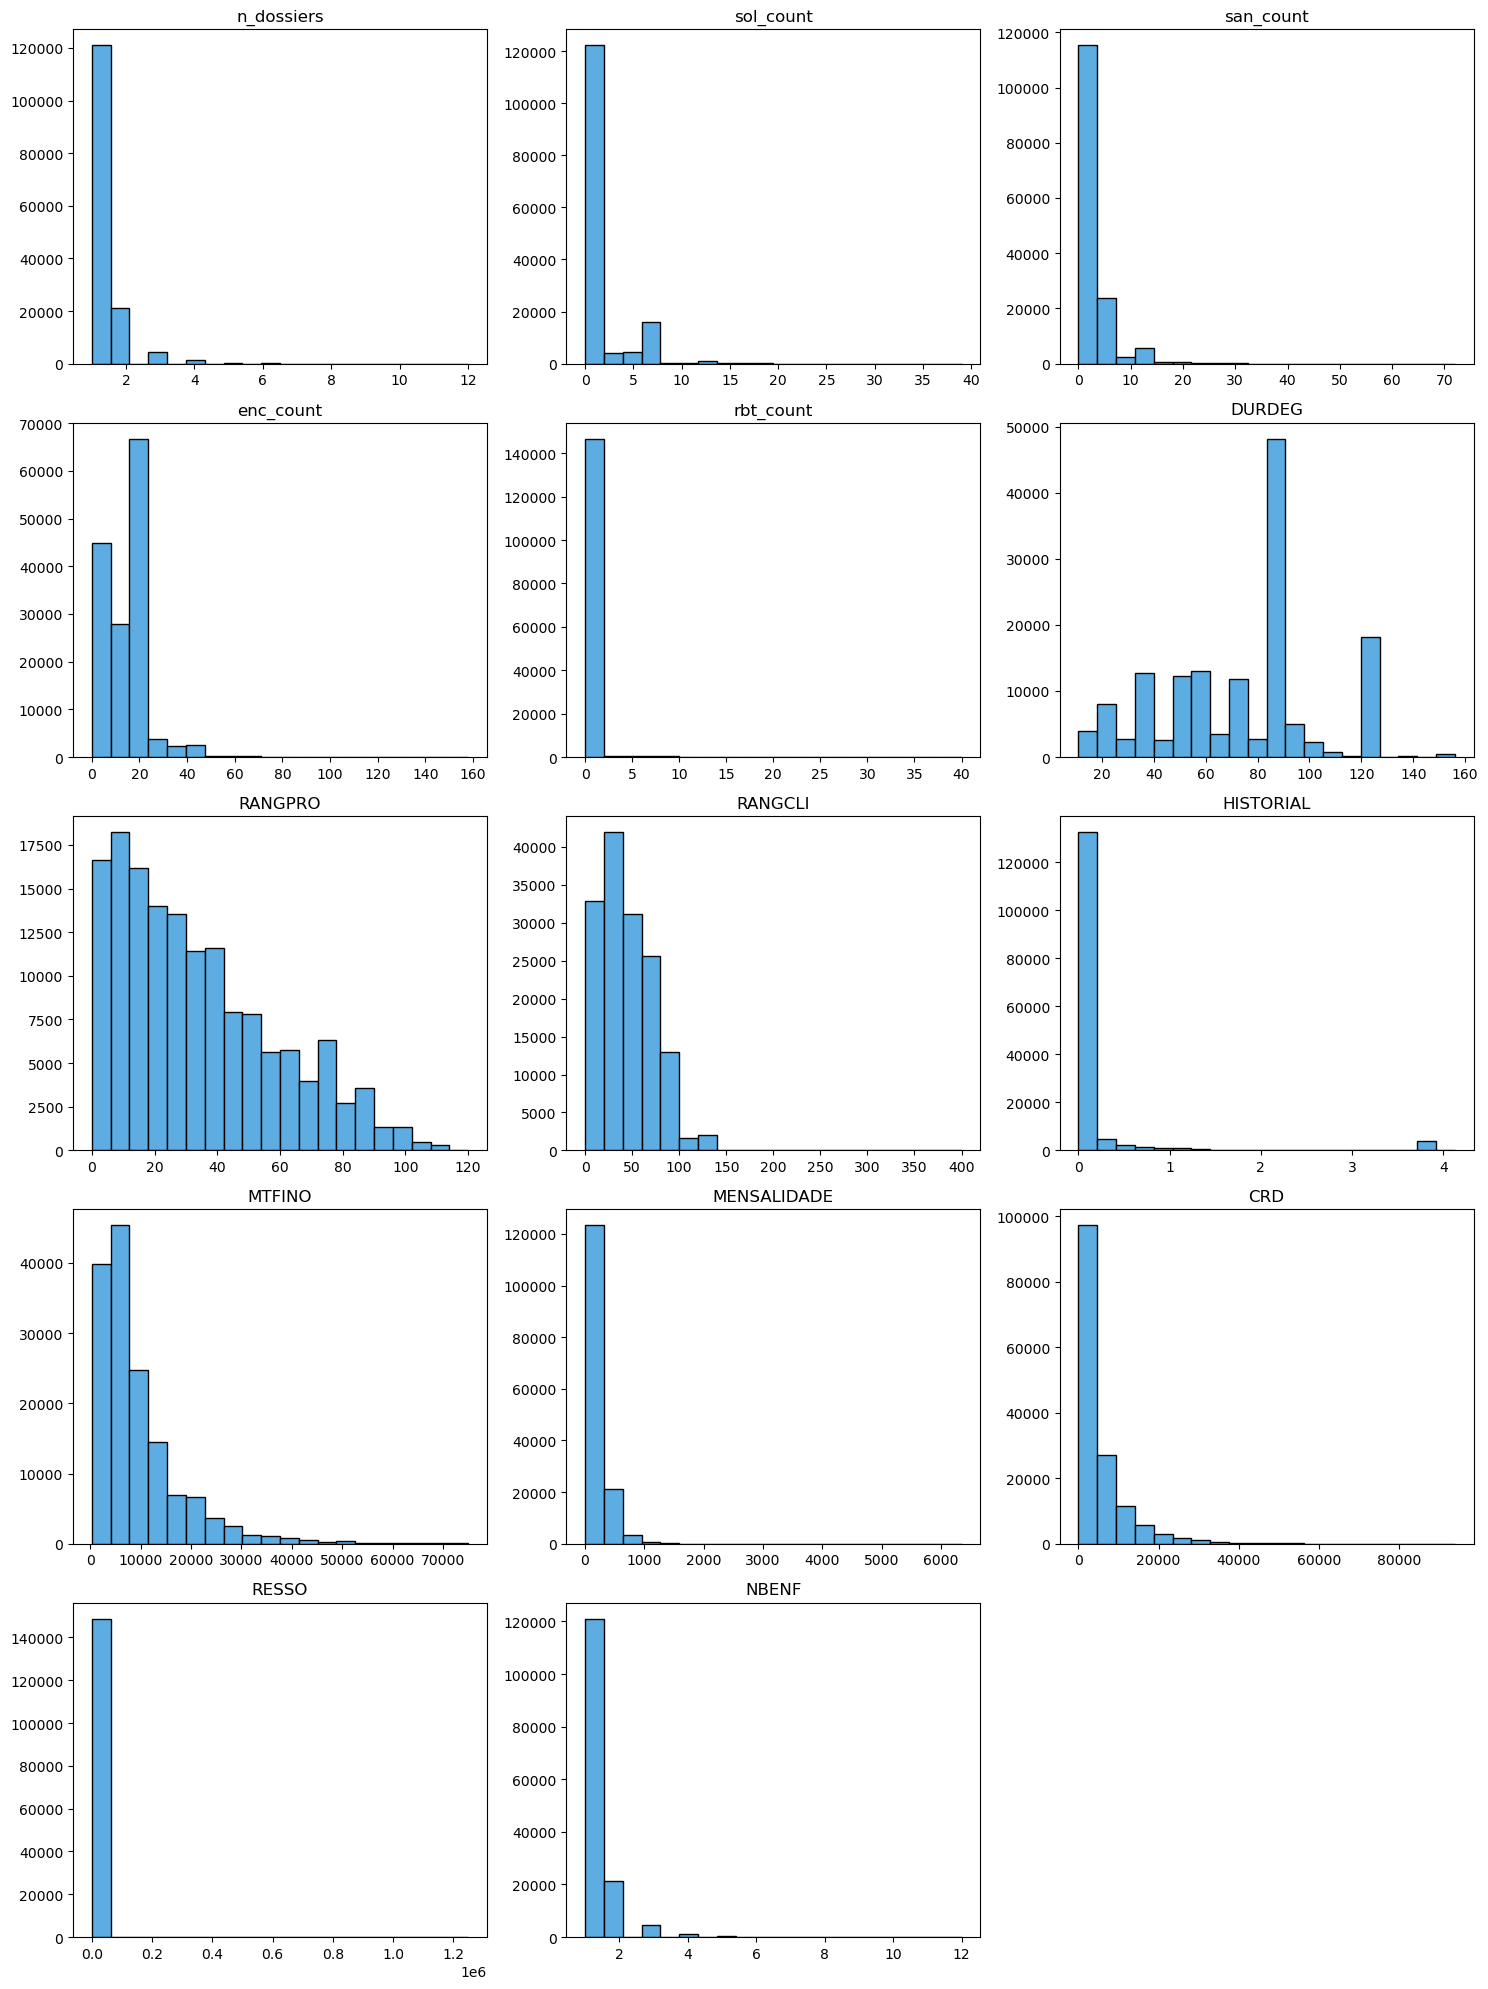

In [167]:
n = len(num_cols)
fig, axes = plt.subplots(nrows = (n // 3) + 1, ncols = 3, figsize = (15, 20))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(agg_clients_num[col].dropna(), bins = 20, color = '#5dade2', edgecolor = 'black')
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    #axes[i].set_ylabel('Frequency')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

C:\Users\jcari\AppData\Local\Temp\ipykernel_26696\1031368143.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[feat] = pd.to_numeric(data[feat], errors="coerce")
C:\Users\jcari\AppData\Local\Temp\ipykernel_26696\1031368143.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[feat] = pd.to_numeric(data[feat], errors="coerce")
C:\Users\jcari\AppData\Local\Temp\ipykernel_26696\1031368143.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .l

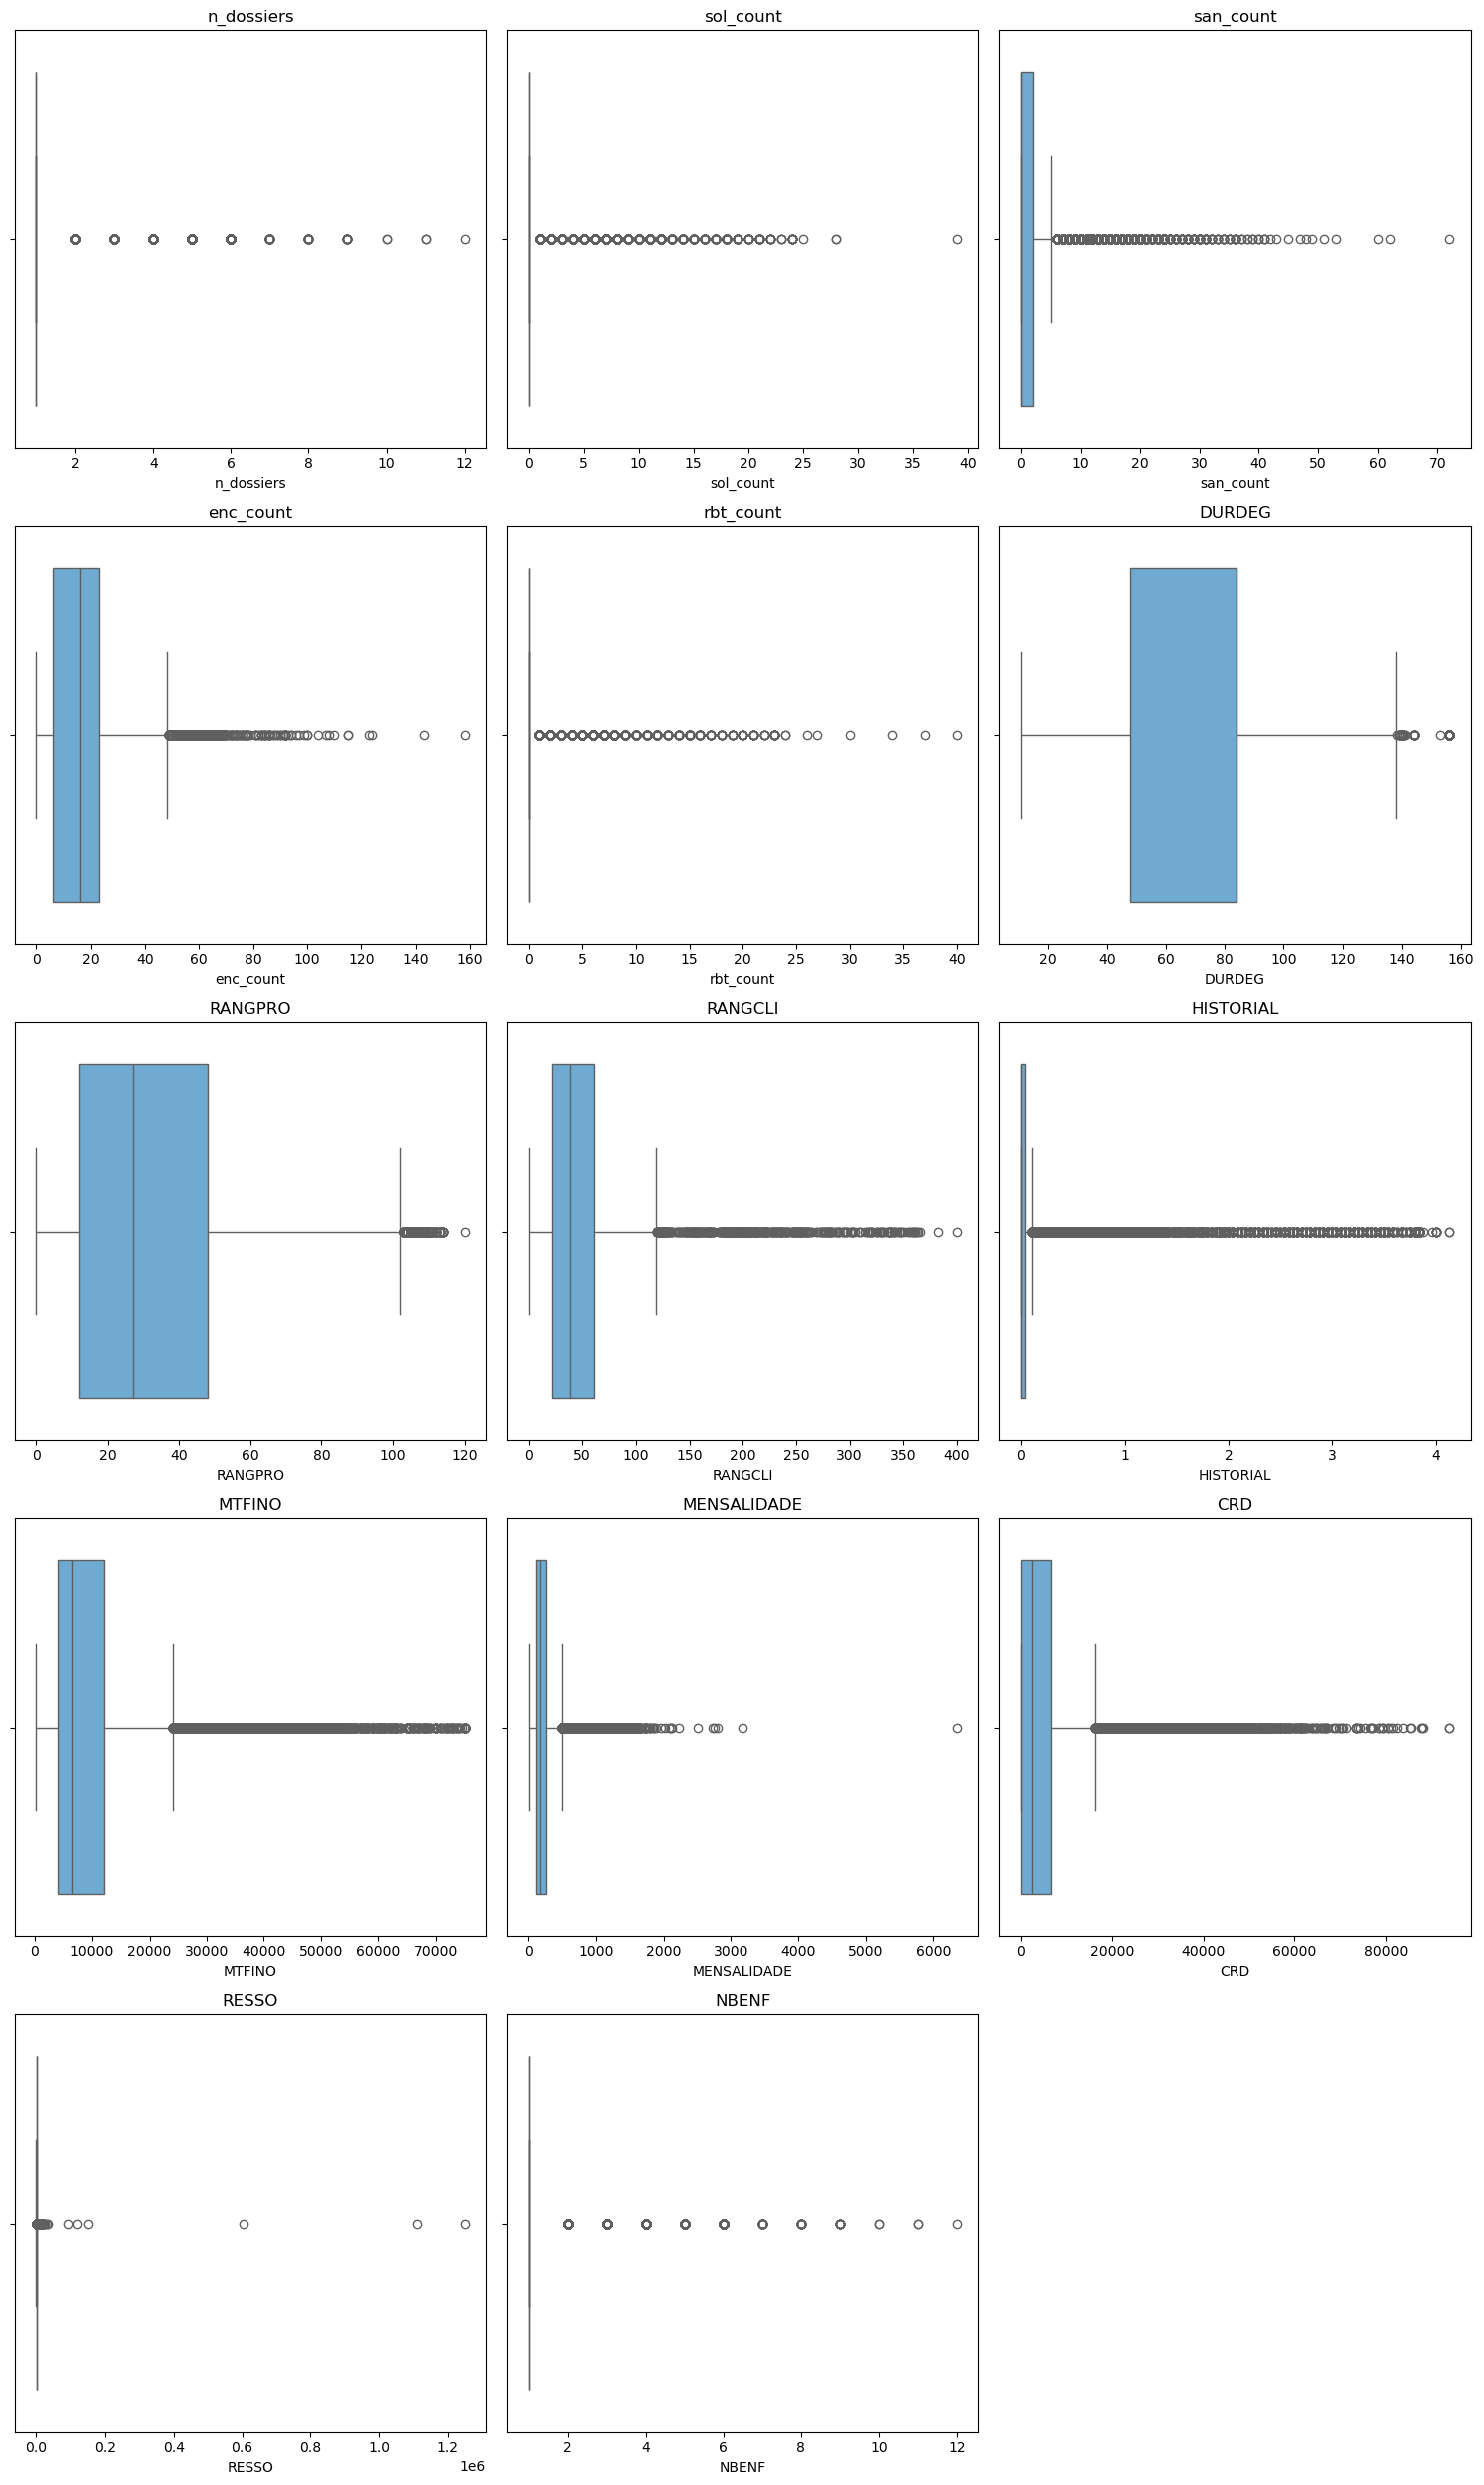

In [166]:
def plot_multiple_boxplots(data, feats):
    
    n = len(feats)  # número de features
    ncols = 3
    nrows = (n // ncols) + (n % ncols > 0)
    
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 5*nrows))
    axes = axes.flatten()
    
    for i, feat in enumerate(feats):
        # garantir que é numérica
        data[feat] = pd.to_numeric(data[feat], errors="coerce")
        
        # remover NaNs para evitar erro
        clean_data = data[feat].dropna()
        
        if len(clean_data) > 0:
            sns.boxplot(x=clean_data, ax=axes[i], color="#5dade2")
            axes[i].set_title(feat)
        else:
            axes[i].set_visible(False)
    
    # remover eixos extra
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])
    
#    plt.suptitle(title, fontsize=20)
    plt.tight_layout()
    plt.show()

plot_multiple_boxplots(agg_clients_num, num_cols)

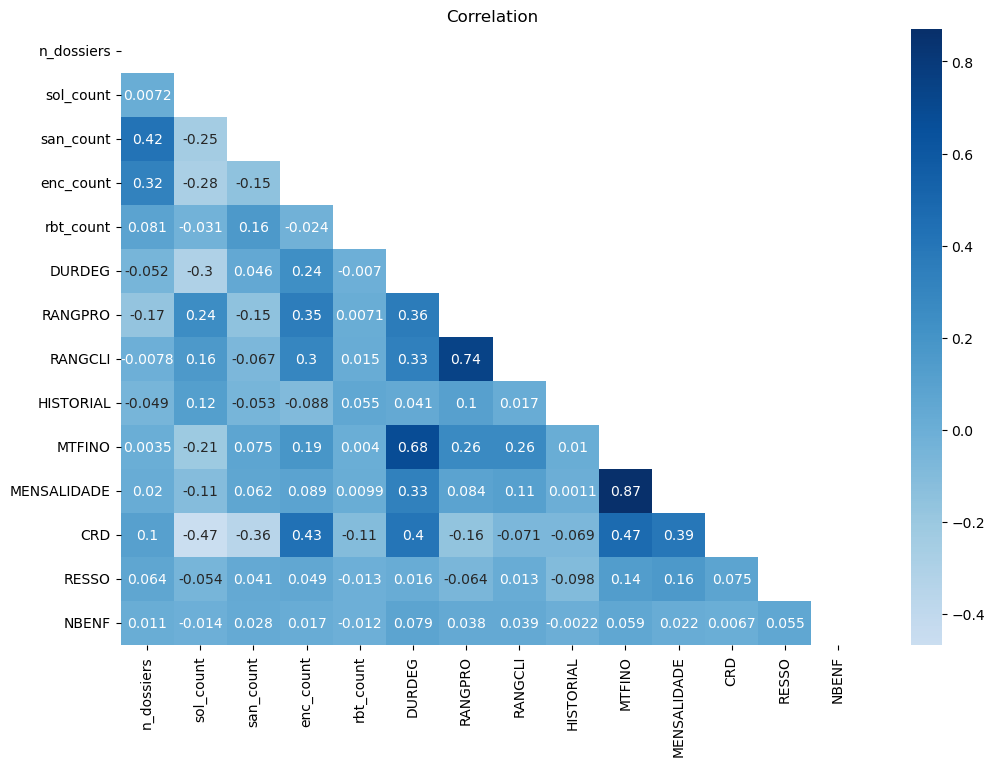

In [149]:
cor_spearman = agg_clients_num.corr(method ='spearman')
#mask = (cor_spearman.abs() < 0.5)
mask = np.triu(np.ones_like(cor_spearman, dtype=bool))

plt.figure(figsize=(12,8))
sns.heatmap(cor_spearman, 
            annot=True, 
            mask=mask,
            cmap = "Blues", 
            center=0)

plt.title("Correlation")
plt.show()

In [150]:
agg_clients_num.isna().sum()

n_dossiers      0
sol_count       0
san_count       0
enc_count       0
rbt_count       0
DURDEG          0
RANGPRO         0
RANGCLI         0
HISTORIAL       0
MTFINO          0
MENSALIDADE     0
CRD             0
RESSO           0
NBENF          40
dtype: int64

In [152]:
agg_clients_num[agg_clients_num['RANGPRO'] == agg_clients_num['RANGCLI']]

,n_dossiers,sol_count,san_count,enc_count,rbt_count,DURDEG,RANGPRO,RANGCLI,HISTORIAL,MTFINO,MENSALIDADE,CRD,RESSO,NBENF
CONTRIB,,,,,,,,,,,,,,
0000ab2116257783438c70ff85a3e98f2d4194ebe534349a33373dfcb3a3a297,1,0,0,23,0,120.0,91.0,91.0,0.000000,20000.000,347.447280,8115.247,1113.258,1.0
0000c74654405ec1da4dbdcd00b86e397954043965d98e542d19fa4808c6b65a,2,12,0,0,0,60.0,21.0,21.0,3.833333,9726.555,304.456898,0.000,678.483,2.0
0000e359b15a80ba12c7f60c0fe06ffc68621c87f13a4f88f54188543d9a09c8,1,0,12,0,0,72.0,34.0,34.0,0.333333,2500.000,56.017772,0.000,838.186,0.0
0000f858346061c53064586a3347b34659565a6712d004e64309c2473f76faed,1,0,0,23,0,84.0,74.0,74.0,0.000000,5000.000,100.073575,883.500,1314.144,2.0
000406feeb8088e3b05f47bc89160d25ca14f11c31f91bc6516a4e6753e58d73,1,6,0,0,0,84.0,24.0,24.0,3.833333,12000.000,274.916857,0.000,797.805,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
fffac57dea1d969a42b214d427e4bf6a3832b0733ee218343545bcb8c7d43719,1,0,0,19,0,84.0,34.0,34.0,0.708333,7750.000,149.986502,6240.644,1455.621,0.0
fffb0b5e039cf837e38c5abe51fb5d9db7366c12609d566f8b44ef3f8a12a349,1,0,0,23,0,120.0,59.0,59.0,0.000000,12500.000,216.051740,9474.858,957.059,0.0
fffc47b191b25cbc3dbc9ce436b94e52d2084144ee5bec31fd2457f3cff87c3c,1,0,0,7,0,36.0,6.0,6.0,0.041667,2000.000,81.856368,1994.881,0.000,2.0


In [153]:
agg_clients_num[agg_clients_num['rbt_count'] == 40]

,n_dossiers,sol_count,san_count,enc_count,rbt_count,DURDEG,RANGPRO,RANGCLI,HISTORIAL,MTFINO,MENSALIDADE,CRD,RESSO,NBENF
CONTRIB,,,,,,,,,,,,,,
a7694a908823a9d442bc440d46fe935d580c605edcc4057992e852b4f969f6da,3,0,0,26,40,76.0,22.0,61.0,0.0,23950.86,531.20642,9331.144667,2774.367174,0.0


In [154]:
knn = KNNImputer(n_neighbors = 5, weights = 'distance')
agg_clients_num['NBENF'] = knn.fit_transform(agg_clients_num)

C:\Users\jcari\AppData\Local\Temp\ipykernel_26696\1736714161.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  agg_clients_num['NBENF'] = knn.fit_transform(agg_clients_num)


In [155]:
agg_clients_num.isna().sum()

n_dossiers     0
sol_count      0
san_count      0
enc_count      0
rbt_count      0
DURDEG         0
RANGPRO        0
RANGCLI        0
HISTORIAL      0
MTFINO         0
MENSALIDADE    0
CRD            0
RESSO          0
NBENF          0
dtype: int64

In [156]:
agg_clients_cat

,AGFIN,PAGAMENTO,CSP,NATIO,PTT,MODCONTACTO
CONTRIB,,,,,,
00008246f87bcc3c17b90629bb183fe2e58795176310f017217d7749af7ee981,118.0,P,80.0,P,8600,W
0000ab2116257783438c70ff85a3e98f2d4194ebe534349a33373dfcb3a3a297,120.0,P,80.0,P,2845,A
0000c74654405ec1da4dbdcd00b86e397954043965d98e542d19fa4808c6b65a,117.0,P,60.0,P,2745,T
0000e359b15a80ba12c7f60c0fe06ffc68621c87f13a4f88f54188543d9a09c8,120.0,N,91.0,P,2855,A
0000f858346061c53064586a3347b34659565a6712d004e64309c2473f76faed,118.0,P,80.0,P,2635,W
...,...,...,...,...,...,...
fffc991d73df732084dab58938d520b8a5d8712474fa53902c42190d5b1e0f9b,118.0,P,80.0,P,4400,W
fffd54b6dbb4cc001fb8ab52a905cff9bdbf14b747be9a9adcf1007f61b9a9c4,120.0,P,80.0,P,9560,W
fffe8c5cbb44ad3ec6154ef5a5208ecd76594a88377f00c5ce4e07c92bfe1f3b,117.0,P,80.0,P,2845,A


In [157]:
for col in agg_clients_cat.columns:
    print(col,len(agg_clients_cat[col].value_counts()))

AGFIN 11
PAGAMENTO 3
CSP 33
NATIO 4
PTT 731
MODCONTACTO 6


In [158]:
agg_clients_cat.isna().sum()

AGFIN             0
PAGAMENTO         0
CSP               0
NATIO             0
PTT               0
MODCONTACTO    5161
dtype: int64

In [159]:
agg_clients_cat['MODCONTACTO'].value_counts()

MODCONTACTO
W    82685
A    59502
T     1099
X      252
V       19
C       11
Name: count, dtype: int64

In [160]:
agg_clients_cat['MODCONTACTO'].fillna(agg_clients_cat['MODCONTACTO'].mode()[0], inplace=True)

C:\Users\jcari\AppData\Local\Temp\ipykernel_26696\2262050263.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  agg_clients_cat['MODCONTACTO'].fillna(agg_clients_cat['MODCONTACTO'].mode()[0], inplace=True)
C:\Users\jcari\AppData\Local\Temp\ipykernel_26696\2262050263.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  agg_clients_cat['MODCONTA

In [161]:
agg_clients_cat.isna().sum()

AGFIN          0
PAGAMENTO      0
CSP            0
NATIO          0
PTT            0
MODCONTACTO    0
dtype: int64

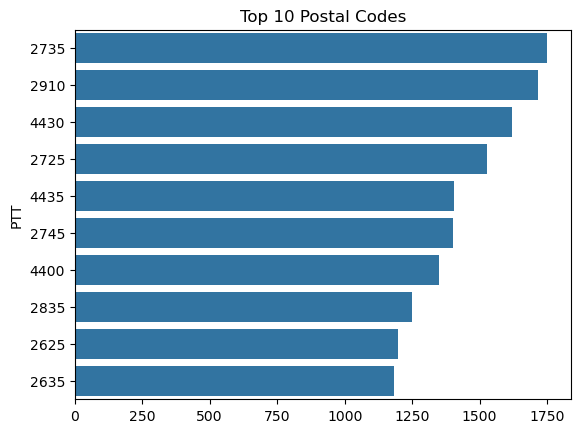

In [162]:
top_postal = agg_clients_cat['PTT'].value_counts().nlargest(10)

sns.barplot(x = top_postal.values, y = top_postal.index)
plt.title('Top 10 Postal Codes')
plt.show()

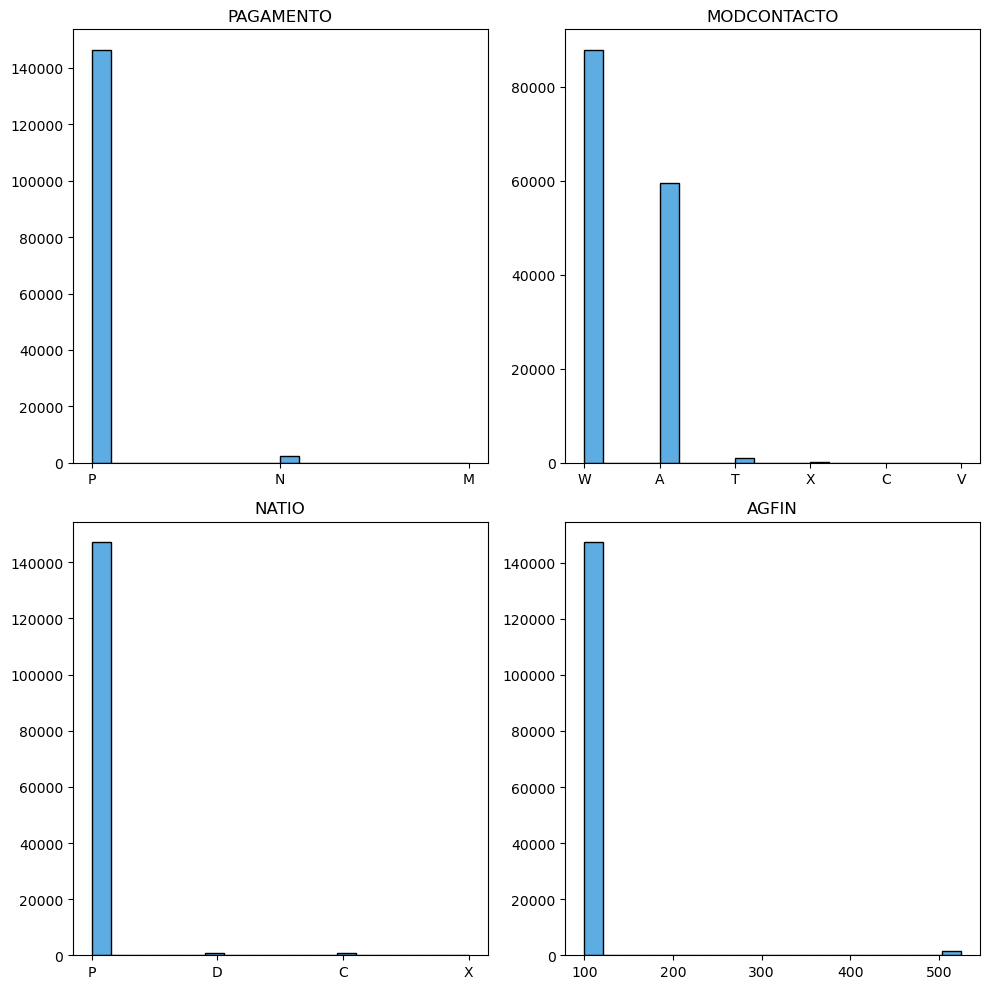

In [163]:
fig, axes = plt.subplots(nrows = 2, ncols = 2, figsize = (10, 10))
axes = axes.flatten()
cols = ['PAGAMENTO', 'MODCONTACTO', 'NATIO', 'AGFIN']
for i, col in enumerate(cols):
    axes[i].hist(agg_clients_cat[col].dropna(), bins = 20, color = '#5dade2', edgecolor = 'black')
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    #axes[i].set_ylabel('Frequency')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [164]:
agg_clients_cat['CSP'].value_counts().nlargest(10)

CSP
80.0    44349
60.0    31826
70.0    13496
31.0    13122
90.0     5363
74.0     4003
15.0     3713
35.0     3663
56.0     3650
32.0     3458
Name: count, dtype: int64

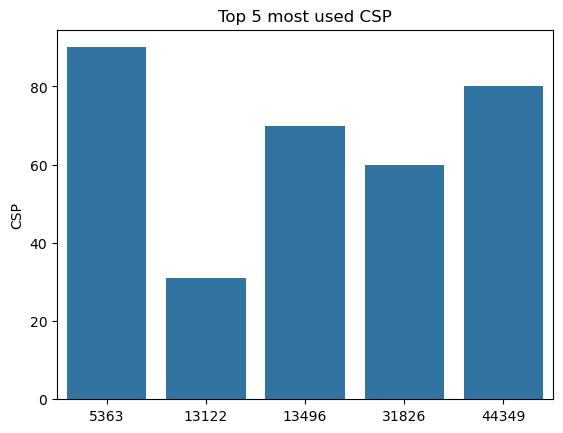

In [165]:
top_csp = agg_clients_cat['CSP'].value_counts().nlargest(5)

sns.barplot(x = top_csp.values, y = top_csp.index)
plt.title('Top 5 most used CSP')
plt.show()

--------